# **Project Name**    -

# Zomato Restaurant Review Sentiment Analysis

##### **Project Type**    - Classification/Natural Language Processing(NLP)
##### **Contribution**    - Individual
##### **Team Member 1 -**  Daksh Birla

# **Project Summary -**

This project focuses on developing a machine learning-based sentiment analysis system for Zomato restaurant reviews. The main objective is to automatically classify customer reviews into positive and negative sentiment categories so that restaurant businesses can better understand customer opinions and identify areas requiring improvement. Customer reviews contain valuable information regarding food quality, service, ambience, staff behaviour, and overall dining experience. However, manually analyzing a large number of reviews can be time-consuming. Therefore, Natural Language Processing (NLP) and machine learning techniques were applied to automate the sentiment classification process.

The project used Zomato restaurant-related datasets containing restaurant information and customer review data. Initial data understanding and exploratory data analysis were performed to examine the structure, quality, and characteristics of the datasets. Missing values, duplicate records, and other data-quality issues were investigated and handled where necessary. Various visualizations were used during exploratory analysis to understand important patterns and relationships within the data and to obtain meaningful business insights from restaurant and review information.

For sentiment modelling, customer review text was preprocessed to make it suitable for machine learning. The textual information was transformed into numerical features using the Term Frequency-Inverse Document Frequency (TF-IDF) technique. TF-IDF represents important words and phrases numerically while reducing the influence of terms that occur frequently across many reviews. This representation is particularly effective for sparse, high-dimensional text classification problems.

Three machine learning classification algorithms were developed and compared: Logistic Regression, Multinomial Naive Bayes, and Linear Support Vector Machine (Linear SVM). The models were evaluated using accuracy, precision, recall, F1-score, classification reports, and confusion matrices. These metrics provided a comprehensive evaluation rather than relying only on overall accuracy. The initial Logistic Regression model achieved approximately 87% testing accuracy with strong precision, recall, and F1-score performance. Multinomial Naive Bayes demonstrated particularly high recall, while Linear SVM also produced competitive classification performance.

Cross-validation and hyperparameter optimization were subsequently performed using GridSearchCV. The technique systematically evaluated different hyperparameter values using multiple cross-validation folds, with F1-score considered during optimization. Hyperparameter tuning improved the overall performance of the models and helped identify parameter configurations that generalized better to unseen data. After comparing the models and their evaluation metrics, Logistic Regression was selected as the final prediction model because of its strong and balanced classification performance as well as its interpretability for text-based sentiment analysis.

Model explainability was performed using the coefficients of the final Logistic Regression model. Because Logistic Regression is a linear algorithm, its coefficients can be interpreted as feature-importance indicators. The most influential positive and negative TF-IDF words and phrases were visualized, providing insight into which textual features contributed most strongly to sentiment predictions. This makes the prediction process more transparent and provides additional business understanding of customer feedback.

Finally, the selected Logistic Regression model and TF-IDF vectorizer were saved using serialized model files for future deployment. The saved files were reloaded and tested on previously unseen restaurant review sentences as a sanity check. The model successfully classified a clearly positive review as positive and a clearly negative review as negative. Overall, the project demonstrates how NLP and machine learning can transform unstructured restaurant reviews into actionable sentiment information that can support customer-experience monitoring, service improvement, and data-driven business decision-making.

# **GitHub Link -**

https://github.com/dakshbirla0710-stack/Zomato-Restaurant-Review-Sentiment-Analysis

# **Problem Statement**


The restaurant industry generates a large amount of customer feedback through online reviews. These reviews contain valuable information about customer satisfaction, food quality, service, ambience, staff behaviour, and the overall dining experience. However, manually analyzing thousands of textual reviews is time-consuming and inefficient for businesses. The objective of this project is to develop a machine learning-based sentiment analysis system that can automatically classify Zomato restaurant reviews into positive and negative sentiment categories. Natural Language Processing techniques and TF-IDF feature extraction are used to convert customer review text into numerical features suitable for machine learning. Multiple classification algorithms are developed, evaluated, and optimized using appropriate evaluation metrics such as accuracy, precision, recall, and F1-score. The final objective is to select a reliable and interpretable model that can help restaurant businesses understand customer sentiment, identify areas of dissatisfaction, improve service quality, and support data-driven decision-making.

# **General Guidelines** : -  

1.   Well-structured, formatted, and commented code is required.
2.   Exception Handling, Production Grade Code & Deployment Ready Code will be a plus. Those students will be awarded some additional credits.
     
     The additional credits will have advantages over other students during Star Student selection.
       
             [ Note: - Deployment Ready Code is defined as, the whole .ipynb notebook should be executable in one go
                       without a single error logged. ]

3.   Each and every logic should have proper comments.
4. You may add as many number of charts you want. Make Sure for each and every chart the following format should be answered.
        

```
# Chart visualization code
```
            

*   Why did you pick the specific chart?
*   What is/are the insight(s) found from the chart?
* Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

5. You have to create at least 15 logical & meaningful charts having important insights.


[ Hints : - Do the Vizualization in  a structured way while following "UBM" Rule.

U - Univariate Analysis,

B - Bivariate Analysis (Numerical - Categorical, Numerical - Numerical, Categorical - Categorical)

M - Multivariate Analysis
 ]





6. You may add more ml algorithms for model creation. Make sure for each and every algorithm, the following format should be answered.


*   Explain the ML Model used and it's performance using Evaluation metric Score Chart.


*   Cross- Validation & Hyperparameter Tuning

*   Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

*   Explain each evaluation metric's indication towards business and the business impact pf the ML model used.




















# ***Let's Begin !***

## ***1. Know Your Data***

### Import Libraries

In [ ]:
# Import Libraries
# Importing required libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

# Display all columns when viewing DataFrames
pd.set_option('display.max_columns', None)

print("Libraries imported successfully!")

Libraries imported successfully!


### Dataset Loading

In [ ]:
# Loading the Zomato datasets

metadata_df = pd.read_csv('/content/Zomato Restaurant names and Metadata.csv')
reviews_df = pd.read_csv('/content/Zomato Restaurant reviews.csv')

print("Metadata Dataset Shape:", metadata_df.shape)
print("Reviews Dataset Shape:", reviews_df.shape)
import pandas as pd
import os

# See exact CSV filenames
print(os.listdir('/content'))

Metadata Dataset Shape: (105, 6)
Reviews Dataset Shape: (10000, 7)
['.config', 'tfidf_vectorizer.pkl', 'Zomato Restaurant names and Metadata.csv', 'final_logistic_regression_model.pkl', 'Zomato Restaurant reviews.csv', 'sample_data']


### Dataset First View

In [ ]:
# First look at the restaurant metadata dataset
print("Restaurant Metadata Dataset:")
display(metadata_df.head())

print("\nRestaurant Reviews Dataset:")
display(reviews_df.head())

Restaurant Metadata Dataset:


,Name,Links,Cost,Collections,Cuisines,Timings
0,Beyond Flavours,https://www.zomato.com/hyderabad/beyond-flavou...,800,"Food Hygiene Rated Restaurants in Hyderabad, C...","Chinese, Continental, Kebab, European, South I...","12noon to 3:30pm, 6:30pm to 11:30pm (Mon-Sun)"
1,Paradise,https://www.zomato.com/hyderabad/paradise-gach...,800,Hyderabad's Hottest,"Biryani, North Indian, Chinese",11 AM to 11 PM
2,Flechazo,https://www.zomato.com/hyderabad/flechazo-gach...,"1,300","Great Buffets, Hyderabad's Hottest","Asian, Mediterranean, North Indian, Desserts","11:30 AM to 4:30 PM, 6:30 PM to 11 PM"
3,Shah Ghouse Hotel & Restaurant,https://www.zomato.com/hyderabad/shah-ghouse-h...,800,Late Night Restaurants,"Biryani, North Indian, Chinese, Seafood, Bever...",12 Noon to 2 AM
4,Over The Moon Brew Company,https://www.zomato.com/hyderabad/over-the-moon...,"1,200","Best Bars & Pubs, Food Hygiene Rated Restauran...","Asian, Continental, North Indian, Chinese, Med...","12noon to 11pm (Mon, Tue, Wed, Thu, Sun), 12no..."



Restaurant Reviews Dataset:


,Restaurant,Reviewer,Review,Rating,Metadata,Time,Pictures
0,Beyond Flavours,Rusha Chakraborty,"The ambience was good, food was quite good . h...",5,"1 Review , 2 Followers",5/25/2019 15:54,0
1,Beyond Flavours,Anusha Tirumalaneedi,Ambience is too good for a pleasant evening. S...,5,"3 Reviews , 2 Followers",5/25/2019 14:20,0
2,Beyond Flavours,Ashok Shekhawat,A must try.. great food great ambience. Thnx f...,5,"2 Reviews , 3 Followers",5/24/2019 22:54,0
3,Beyond Flavours,Swapnil Sarkar,Soumen das and Arun was a great guy. Only beca...,5,"1 Review , 1 Follower",5/24/2019 22:11,0
4,Beyond Flavours,Dileep,Food is good.we ordered Kodi drumsticks and ba...,5,"3 Reviews , 2 Followers",5/24/2019 21:37,0


### Dataset Rows & Columns count

In [ ]:
# Checking the number of rows and columns in both datasets

print("Restaurant Metadata Dataset:")
print("Rows:", metadata_df.shape[0])
print("Columns:", metadata_df.shape[1])

print("\nRestaurant Reviews Dataset:")
print("Rows:", reviews_df.shape[0])
print("Columns:", reviews_df.shape[1])

Restaurant Metadata Dataset:
Rows: 105
Columns: 6

Restaurant Reviews Dataset:
Rows: 10000
Columns: 7


### Dataset Information

In [ ]:
# Checking the structure and data types of both datasets

print("Restaurant Metadata Dataset Information:")
metadata_df.info()

print("\n" + "="*60 + "\n")

print("Restaurant Reviews Dataset Information:")
reviews_df.info()

Restaurant Metadata Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 105 entries, 0 to 104
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Name         105 non-null    object
 1   Links        105 non-null    object
 2   Cost         105 non-null    object
 3   Collections  51 non-null     object
 4   Cuisines     105 non-null    object
 5   Timings      104 non-null    object
dtypes: object(6)
memory usage: 5.1+ KB


Restaurant Reviews Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Restaurant  10000 non-null  object
 1   Reviewer    9962 non-null   object
 2   Review      9955 non-null   object
 3   Rating      9962 non-null   object
 4   Metadata    9962 non-null   object
 5   Time        9962 non-null   object
 6   Pictures    1

#### Duplicate Values

In [ ]:
# Checking duplicate rows in both datasets

metadata_duplicates = metadata_df.duplicated().sum()
reviews_duplicates = reviews_df.duplicated().sum()

print("Duplicate rows in Metadata Dataset:", metadata_duplicates)
print("Duplicate rows in Reviews Dataset:", reviews_duplicates)

Duplicate rows in Metadata Dataset: 0
Duplicate rows in Reviews Dataset: 36


#### Missing Values/Null Values

In [ ]:
# Checking missing values in both datasets

print("Missing Values - Metadata Dataset:")
print(metadata_df.isnull().sum())

print("\nMissing Values - Reviews Dataset:")
print(reviews_df.isnull().sum())

Missing Values - Metadata Dataset:
Name            0
Links           0
Cost            0
Collections    54
Cuisines        0
Timings         1
dtype: int64

Missing Values - Reviews Dataset:
Restaurant     0
Reviewer      38
Review        45
Rating        38
Metadata      38
Time          38
Pictures       0
dtype: int64


In [ ]:
# Calculating the percentage of missing values

metadata_missing_percentage = (
    metadata_df.isnull().sum() / len(metadata_df) * 100
).sort_values(ascending=False)

reviews_missing_percentage = (
    reviews_df.isnull().sum() / len(reviews_df) * 100
).sort_values(ascending=False)

print("Missing Value Percentage - Metadata Dataset:")
display(metadata_missing_percentage)

print("\nMissing Value Percentage - Reviews Dataset:")
display(reviews_missing_percentage)

Missing Value Percentage - Metadata Dataset:


,0
Collections,51.428571
Timings,0.952381
Links,0.000000
Name,0.000000
Cost,0.000000
Cuisines,0.000000



Missing Value Percentage - Reviews Dataset:


,0
Review,0.45
Reviewer,0.38
Rating,0.38
Time,0.38
Metadata,0.38
Restaurant,0.00
Pictures,0.00


### What did you know about your dataset?

The project uses two Zomato datasets containing restaurant information and customer review information. The restaurant metadata dataset provides restaurant-level attributes such as restaurant name, links, cost, collection information, cuisines, timings, and related characteristics. The reviews dataset contains customer-level information such as restaurant name, reviewer details, review text, rating, metadata, time, pictures, and other review-related attributes. Initial inspection of the datasets was performed using shape, data types, descriptive statistics, missing-value analysis, and duplicate-value checks. The review text is particularly important for this project because it provides the unstructured textual information required for sentiment classification. The rating information is used to derive the sentiment target, while the review text is subsequently processed and converted into TF-IDF features for machine learning.

## ***2. Understanding Your Variables***

In [ ]:
# Display columns of both datasets

print("Restaurant Metadata Dataset Columns:")
print(metadata_df.columns.tolist())

print("\nRestaurant Reviews Dataset Columns:")
print(reviews_df.columns.tolist())

Restaurant Metadata Dataset Columns:
['Name', 'Links', 'Cost', 'Collections', 'Cuisines', 'Timings']

Restaurant Reviews Dataset Columns:
['Restaurant', 'Reviewer', 'Review', 'Rating', 'Metadata', 'Time', 'Pictures']


In [ ]:
# Descriptive statistics of both datasets

print("Restaurant Metadata Dataset:")
display(metadata_df.describe(include='all').T)

print("\nRestaurant Reviews Dataset:")
display(reviews_df.describe(include='all').T)

Restaurant Metadata Dataset:


,count,unique,top,freq
Name,105,105,Beyond Flavours,1
Links,105,105,https://www.zomato.com/hyderabad/beyond-flavou...,1
Cost,105,29,500,13
Collections,51,42,Food Hygiene Rated Restaurants in Hyderabad,4
Cuisines,105,92,"North Indian, Chinese",4
Timings,104,77,11 AM to 11 PM,6



Restaurant Reviews Dataset:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Restaurant,10000,100,Beyond Flavours,100,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Reviewer,9962,7446,Parijat Ray,13,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Review,9955,9364,good,237,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Rating,9962,10,5,3832,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Metadata,9962,2477,1 Review,919,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Time,9962,9782,7/29/2018 20:34,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Pictures,10000.0,NaN,NaN,NaN,0.7486,2.570381,0.0,0.0,0.0,0.0,64.0


### Variables Description

The dataset contains both restaurant-level and review-level variables. Restaurant-level variables describe characteristics such as restaurant name, cuisine, approximate cost, timings, collections, and other restaurant information. Review-level variables contain information related to individual customer feedback, including reviewer details, review text, rating, review time, metadata, and pictures. For the machine learning component, the Review variable acts as the primary textual input feature because it contains the customer's written feedback. The Rating variable represents the customer's evaluation and is used to derive the sentiment target variable. The resulting sentiment variable represents the classification outcome, where reviews are categorized into positive or negative sentiment. After text preprocessing, the Review variable is transformed into numerical TF-IDF features that can be provided to the machine learning classification algorithms.

### Check Unique Values for each variable.

In [ ]:
# Check unique values for each variable

print("Unique values in Restaurant Metadata Dataset:")
print("-" * 50)

for column in metadata_df.columns:
    print(f"{column}: {metadata_df[column].nunique()} unique values")


print("\nUnique values in Restaurant Reviews Dataset:")
print("-" * 50)

for column in reviews_df.columns:
    print(f"{column}: {reviews_df[column].nunique()} unique values")

Unique values in Restaurant Metadata Dataset:
--------------------------------------------------
Name: 105 unique values
Links: 105 unique values
Cost: 29 unique values
Collections: 42 unique values
Cuisines: 92 unique values
Timings: 77 unique values

Unique values in Restaurant Reviews Dataset:
--------------------------------------------------
Restaurant: 100 unique values
Reviewer: 7446 unique values
Review: 9364 unique values
Rating: 10 unique values
Metadata: 2477 unique values
Time: 9782 unique values
Pictures: 36 unique values


## 3. ***Data Wrangling***

### Data Wrangling Code

In [ ]:
# ============================
# DATA WRANGLING / CLEANING
# ============================

# 1. Remove exact duplicate rows from the reviews dataset
before_duplicates = len(reviews_df)

reviews_df = reviews_df.drop_duplicates().reset_index(drop=True)

after_duplicates = len(reviews_df)

print("Duplicate rows removed:", before_duplicates - after_duplicates)
print("Reviews dataset shape after removing duplicates:", reviews_df.shape)


# 2. Handle missing values in the metadata dataset
# Collections has many missing values, so we retain the restaurants
# and mark unavailable information explicitly.

metadata_df['Collections'] = metadata_df['Collections'].fillna('Not Available')
metadata_df['Timings'] = metadata_df['Timings'].fillna('Not Available')


# 3. Remove reviews where the actual review text is missing
# Review text is essential for sentiment/NLP analysis.

before_missing_review = len(reviews_df)

reviews_df = reviews_df.dropna(subset=['Review']).reset_index(drop=True)

after_missing_review = len(reviews_df)

print("Rows removed due to missing Review:",
      before_missing_review - after_missing_review)


# 4. Check the final datasets
print("\nFinal Metadata Dataset Shape:", metadata_df.shape)
print("Final Reviews Dataset Shape:", reviews_df.shape)

print("\nRemaining Missing Values - Metadata:")
print(metadata_df.isnull().sum())

print("\nRemaining Missing Values - Reviews:")
print(reviews_df.isnull().sum())

Duplicate rows removed: 36
Reviews dataset shape after removing duplicates: (9964, 7)
Rows removed due to missing Review: 9

Final Metadata Dataset Shape: (105, 6)
Final Reviews Dataset Shape: (9955, 7)

Remaining Missing Values - Metadata:
Name           0
Links          0
Cost           0
Collections    0
Cuisines       0
Timings        0
dtype: int64

Remaining Missing Values - Reviews:
Restaurant    0
Reviewer      0
Review        0
Rating        0
Metadata      0
Time          0
Pictures      0
dtype: int64


### What all manipulations have you done and insights you found?

Data Wrangling and Insights:

1. The restaurant metadata dataset initially contained 105 rows and 6 columns, while the restaurant reviews dataset contained 10,000 rows and 7 columns.

2. We checked for duplicate records and found 36 exact duplicate rows in the reviews dataset. These duplicate rows were removed to avoid repeated observations.

3. The metadata dataset contained missing values mainly in the Collections column. Since removing these restaurants would result in significant data loss, the missing values were replaced with "Not Available". The single missing value in Timings was handled similarly.

4. The reviews dataset contained some missing values. Since review text is essential for text and sentiment analysis, rows where the Review field was missing were removed.

5. After data wrangling, the metadata dataset remained at 105 rows and 6 columns, while the reviews dataset contained 9,955 rows and 7 columns.

6. Finally, the datasets were checked again and no missing values remained in either dataset, making the data ready for further analysis and visualization.

## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

#### Chart - 1

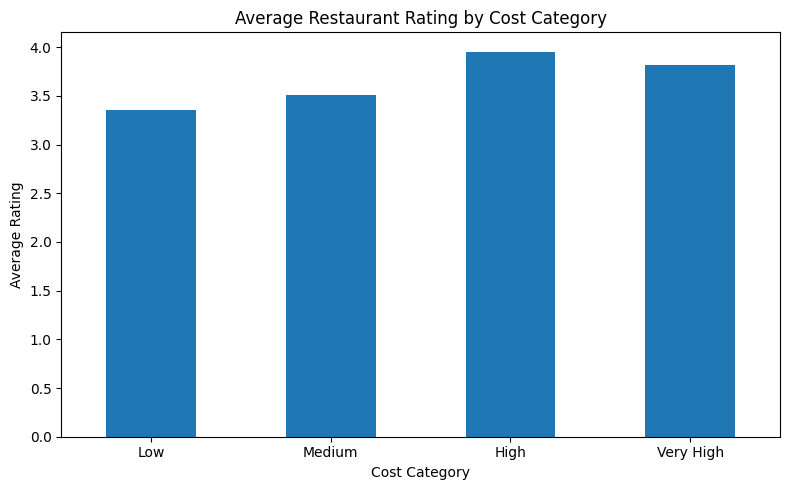

In [ ]:
# Chart 1: Average Restaurant Rating by Cost Category

import matplotlib.pyplot as plt
import pandas as pd

# Convert Rating to numeric
reviews_df['Rating_numeric'] = pd.to_numeric(
    reviews_df['Rating'].astype(str).str.extract(r'(\d+\.?\d*)')[0],
    errors='coerce'
)

# Clean Cost column
metadata_df['Cost_clean'] = (
    metadata_df['Cost']
    .astype(str)
    .str.replace(',', '', regex=False)
    .str.extract(r'(\d+\.?\d*)')[0]
)

metadata_df['Cost_clean'] = pd.to_numeric(
    metadata_df['Cost_clean'],
    errors='coerce'
)

# Merge the two datasets using restaurant name
merged_df = reviews_df.merge(
    metadata_df[['Name', 'Cost_clean']],
    left_on='Restaurant',
    right_on='Name',
    how='inner'
)

# Remove rows where rating or cost is unavailable
chart1_df = merged_df.dropna(
    subset=['Rating_numeric', 'Cost_clean']
)

# Create cost categories
chart1_df['Cost Category'] = pd.cut(
    chart1_df['Cost_clean'],
    bins=[0, 500, 1000, 2000, float('inf')],
    labels=['Low', 'Medium', 'High', 'Very High']
)

# Calculate average rating for each cost category
avg_rating = (
    chart1_df.groupby('Cost Category', observed=True)['Rating_numeric']
    .mean()
)

# Plot
plt.figure(figsize=(8, 5))
avg_rating.plot(kind='bar')

plt.title('Average Restaurant Rating by Cost Category')
plt.xlabel('Cost Category')
plt.ylabel('Average Rating')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

I selected a bar chart because it makes it easy to compare the average restaurant ratings across different cost categories. It clearly shows how the average rating changes as the restaurant cost increases.

##### 2. What is/are the insight(s) found from the chart?

The chart shows that restaurants in the High cost category have the highest average rating, followed by Very High cost restaurants. Low-cost restaurants have the lowest average rating. This suggests that higher-priced restaurants tend to receive better ratings in this dataset.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, these insights can help restaurants understand the relationship between pricing and customer ratings. Higher-cost restaurants can focus on maintaining their service and food quality, while lower-cost restaurants can improve their offerings and customer experience to increase their ratings.

#### Chart - 2

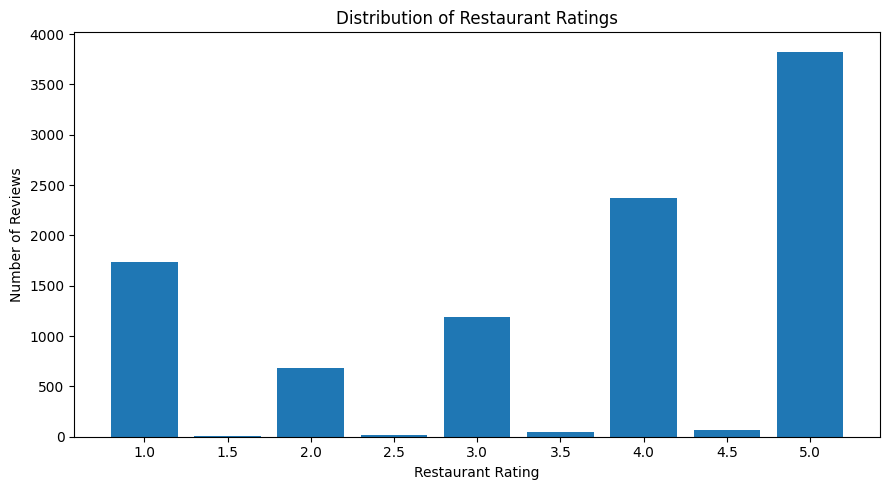

In [ ]:
# Chart 2: Distribution of Restaurant Ratings

# Convert ratings to numeric
rating_data = pd.to_numeric(
    reviews_df['Rating'].astype(str).str.extract(r'(\d+\.?\d*)')[0],
    errors='coerce'
).dropna()

# Count each rating
rating_counts = rating_data.value_counts().sort_index()

# Create bar chart
plt.figure(figsize=(9, 5))

plt.bar(
    rating_counts.index.astype(str),
    rating_counts.values
)

plt.title('Distribution of Restaurant Ratings')
plt.xlabel('Restaurant Rating')
plt.ylabel('Number of Reviews')

plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

I selected a bar chart because it clearly compares the frequency of different restaurant ratings. It makes it easy to identify which ratings are most common among customers.

##### 2. What is/are the insight(s) found from the chart?

The chart shows that 5-star ratings are the most frequent, followed by 4-star ratings. This indicates that a large proportion of customers had a positive experience. However, there is also a noticeable number of 1-star reviews, showing that some customers had very negative experiences.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. Restaurants can use the high ratings to understand what customers appreciate and maintain those standards. At the same time, analysing the 1-star reviews can help identify common customer complaints and areas that need improvement.

#### Chart - 3

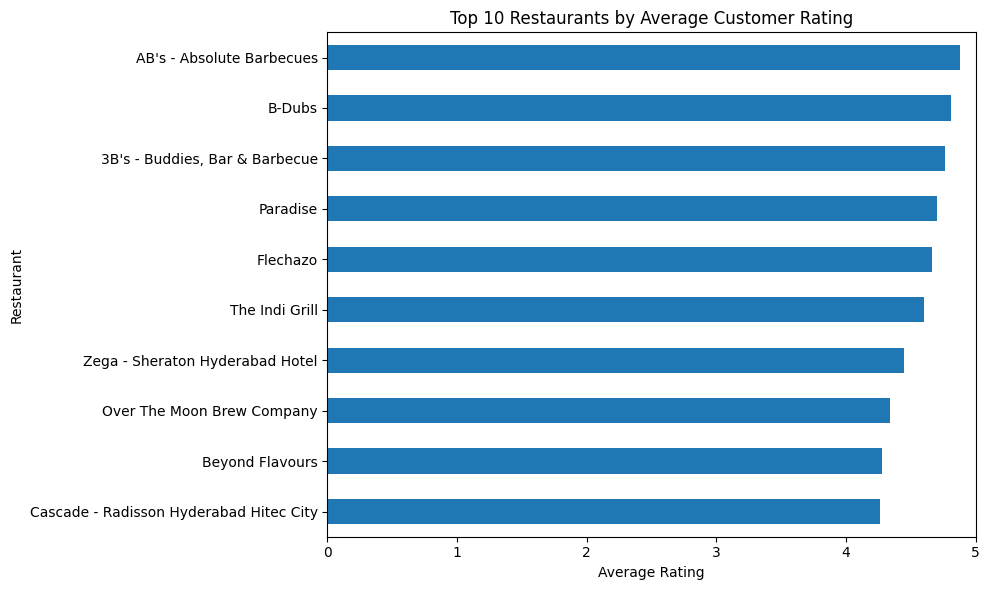

In [ ]:
# Chart 3: Top 10 Restaurants by Average Rating

# Calculate average rating for each restaurant
restaurant_avg_rating = (
    reviews_df.groupby('Restaurant')['Rating_numeric']
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

# Create horizontal bar chart
plt.figure(figsize=(10, 6))

restaurant_avg_rating.sort_values().plot(kind='barh')

plt.title('Top 10 Restaurants by Average Customer Rating')
plt.xlabel('Average Rating')
plt.ylabel('Restaurant')

plt.xlim(0, 5)
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

I selected a horizontal bar chart because it is suitable for comparing the average ratings of different restaurants. The horizontal format also makes long restaurant names easier to read and helps identify the highest-rated restaurants quickly.

##### 2. What is/are the insight(s) found from the chart?

The chart shows that AB's - Absolute Barbecues has the highest average customer rating, followed by B-Dubs and 3B's - Buddies, Bar & Barbecue. The top 10 restaurants all have relatively high average ratings, indicating strong customer satisfaction among these restaurants.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. Identifying highly rated restaurants can help understand which restaurants are delivering strong customer experiences. Other restaurants can study the food quality, service and overall customer experience of these top performers. Restaurants with lower ratings can use such comparisons to identify areas for improvement and avoid negative business growth caused by poor customer satisfaction.

#### Chart - 4

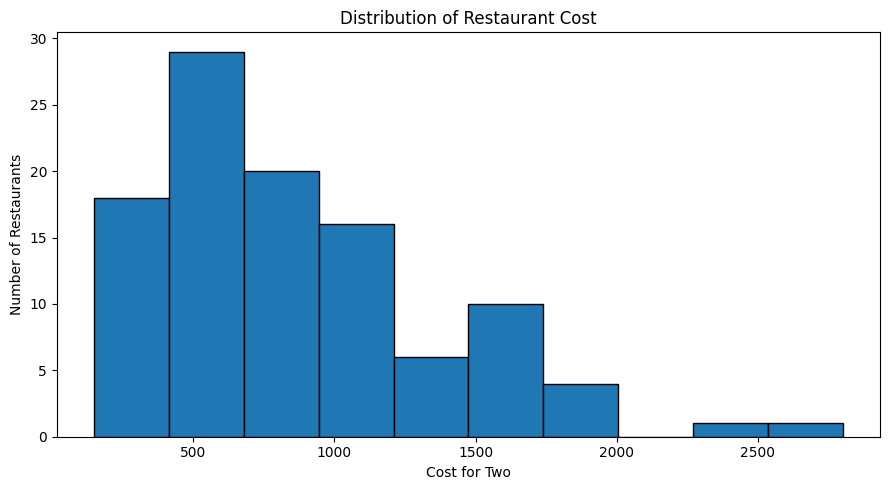

Minimum Cost: 150
Maximum Cost: 2800
Average Cost: 861.43
Median Cost: 700.0


In [ ]:
# Chart 4: Distribution of Restaurant Cost

# Use the cleaned cost column created earlier
cost_data = metadata_df['Cost_clean'].dropna()

# Create histogram
plt.figure(figsize=(9, 5))

plt.hist(cost_data, bins=10, edgecolor='black')

plt.title('Distribution of Restaurant Cost')
plt.xlabel('Cost for Two')
plt.ylabel('Number of Restaurants')

plt.tight_layout()
plt.show()

# Display basic cost statistics
print("Minimum Cost:", cost_data.min())
print("Maximum Cost:", cost_data.max())
print("Average Cost:", round(cost_data.mean(), 2))
print("Median Cost:", cost_data.median())

##### 1. Why did you pick the specific chart?

I selected a histogram because restaurant cost is a numerical variable, and a histogram clearly shows how restaurants are distributed across different price ranges. It helps identify the most common cost ranges as well as unusually expensive restaurants.

##### 2. What is/are the insight(s) found from the chart?

The restaurant cost ranges from ₹150 to ₹2,800 for two people. The average cost is approximately ₹861, while the median cost is ₹700. Most restaurants are concentrated in the lower and medium price ranges, while only a small number of restaurants have very high costs. The average being higher than the median also indicates that expensive restaurants are pulling the average upward.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. This information can help understand the pricing structure of the restaurant market. Since most restaurants are concentrated in affordable and mid-range price segments, businesses can use this information while deciding their pricing strategy. Very high pricing may limit the target customer base unless it is supported by better food quality, service and customer experience.

#### Chart - 5

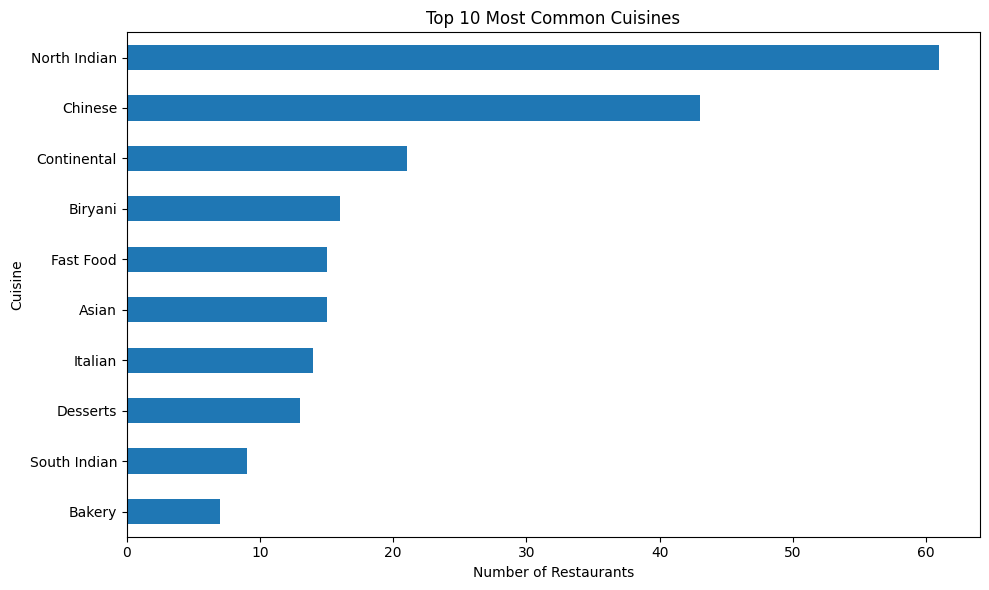

Top 10 Cuisines:
Cuisines
North Indian    61
Chinese         43
Continental     21
Biryani         16
Asian           15
Fast Food       15
Italian         14
Desserts        13
South Indian     9
Bakery           7
Name: count, dtype: int64


In [ ]:
# Chart 5: Top 10 Most Common Cuisines

# Split cuisine combinations into individual cuisines
cuisine_counts = (
    metadata_df['Cuisines']
    .dropna()
    .str.split(',')
    .explode()
    .str.strip()
    .value_counts()
    .head(10)
)

# Create horizontal bar chart
plt.figure(figsize=(10, 6))

cuisine_counts.sort_values().plot(kind='barh')

plt.title('Top 10 Most Common Cuisines')
plt.xlabel('Number of Restaurants')
plt.ylabel('Cuisine')

plt.tight_layout()
plt.show()

# Display exact counts
print("Top 10 Cuisines:")
print(cuisine_counts)

##### 1. Why did you pick the specific chart?

A horizontal bar chart was selected because it clearly compares the frequency of different cuisines and makes it easy to identify the most commonly offered cuisines.

##### 2. What is/are the insight(s) found from the chart?

North Indian is the most commonly offered cuisine, appearing in more than 60 restaurants, followed by Chinese with more than 40 restaurants. Continental is the third most common cuisine. Other cuisines such as Biryani, Fast Food, Asian, Italian and Desserts have comparatively lower representation.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

These insights can help restaurants understand the competitive landscape and plan their menu offerings. The strong presence of North Indian and Chinese cuisines indicates high availability and potentially strong competition in these categories. Restaurants may differentiate themselves through food quality, pricing, service or unique menu options. Less represented cuisines may provide opportunities for differentiation, although lower representation does not necessarily indicate lower customer demand.

#### Chart - 6

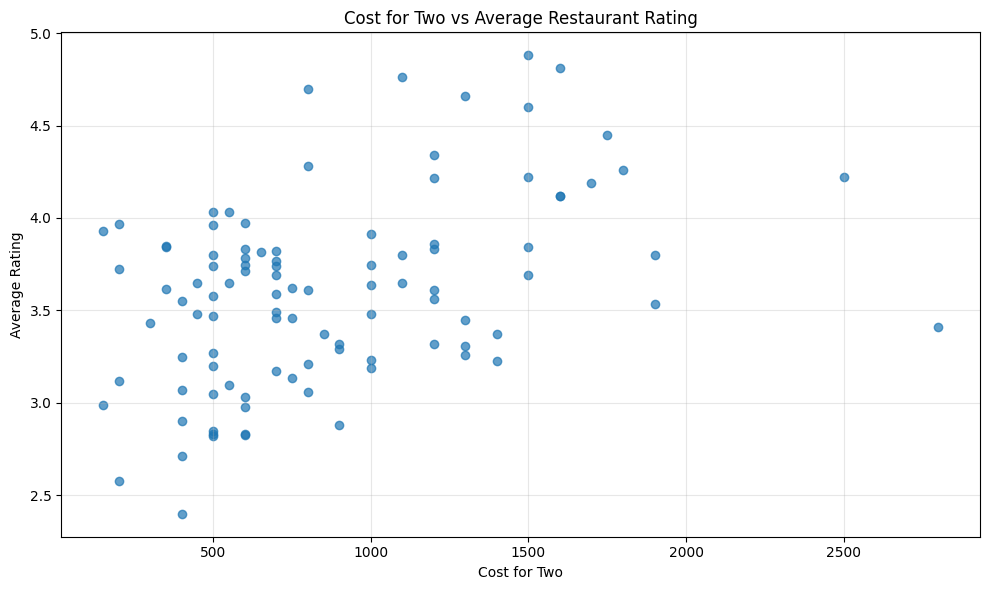

Correlation between Cost and Average Rating: 0.42


In [ ]:
# Chart 6: Cost for Two vs Average Restaurant Rating

# Calculate average rating for each restaurant
cost_rating_df = (
    merged_df.groupby(['Restaurant', 'Cost_clean'])['Rating_numeric']
    .mean()
    .reset_index()
)

# Remove missing values
cost_rating_df = cost_rating_df.dropna(
    subset=['Cost_clean', 'Rating_numeric']
)

# Scatter plot
plt.figure(figsize=(10, 6))

plt.scatter(
    cost_rating_df['Cost_clean'],
    cost_rating_df['Rating_numeric'],
    alpha=0.7
)

plt.title('Cost for Two vs Average Restaurant Rating')
plt.xlabel('Cost for Two')
plt.ylabel('Average Rating')

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Calculate correlation
correlation = cost_rating_df['Cost_clean'].corr(
    cost_rating_df['Rating_numeric']
)

print("Correlation between Cost and Average Rating:",
      round(correlation, 2))

##### 1. Why did you pick the specific chart?

A scatter plot was selected because it is suitable for analyzing the relationship between two numerical variables: cost for two and average restaurant rating. It helps identify whether higher-priced restaurants tend to receive higher customer ratings.

##### 2. What is/are the insight(s) found from the chart?

The chart shows a moderate positive relationship between restaurant cost and average rating. The correlation value is 0.42, indicating that restaurants with higher costs generally tend to have somewhat higher ratings. However, the scattered points also show that higher cost does not always guarantee a higher customer rating.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, this insight can help restaurants make better pricing and service decisions. Since higher cost has only a moderate relationship with higher ratings, restaurants should focus on food quality, service and customer experience rather than simply increasing prices. Expensive restaurants with comparatively low ratings may face negative growth because customers may feel that they are not receiving sufficient value for the price paid.

#### Chart - 7

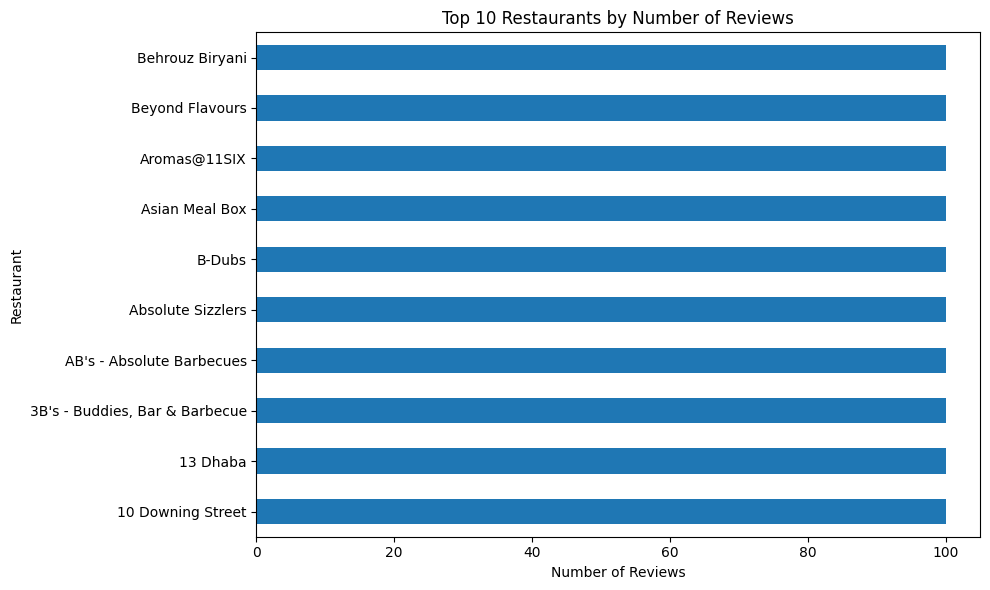

Top 10 Restaurants by Number of Reviews:
Restaurant
10 Downing Street                 100
13 Dhaba                          100
3B's - Buddies, Bar & Barbecue    100
AB's - Absolute Barbecues         100
Absolute Sizzlers                 100
B-Dubs                            100
Asian Meal Box                    100
Aromas@11SIX                      100
Beyond Flavours                   100
Behrouz Biryani                   100
dtype: int64


In [ ]:
# Chart - 7 visualization code

# Count number of reviews for each restaurant
review_counts = merged_df.groupby('Restaurant').size().sort_values(ascending=False).head(10)

# Plot
plt.figure(figsize=(10, 6))
review_counts.sort_values().plot(kind='barh')

plt.title('Top 10 Restaurants by Number of Reviews')
plt.xlabel('Number of Reviews')
plt.ylabel('Restaurant')

plt.tight_layout()
plt.show()

# Display values
print("Top 10 Restaurants by Number of Reviews:")
print(review_counts)

##### 1. Why did you pick the specific chart?

A horizontal bar chart was selected because it clearly compares the number of customer reviews across different restaurants. It also makes long restaurant names easy to read and helps identify the most reviewed restaurants quickly.

##### 2. What is/are the insight(s) found from the chart?

The chart shows that the Top 10 most reviewed restaurants each have 100 reviews. Restaurants such as Behrouz Biryani, Beyond Flavours, Aromas@11SIX, Asian Meal Box, B-Dubs and others therefore show equally high customer engagement in this dataset. There is no single restaurant dominating the Top 10 based on review count.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. Review counts can help identify restaurants with high customer engagement and visibility. Restaurants with many reviews can be studied to understand successful practices related to food, service and customer experience. Restaurants with fewer reviews may indicate lower customer engagement or visibility, which could negatively affect growth. Such restaurants can improve promotions, customer experience and encourage customers to provide feedback.

#### Chart - 8

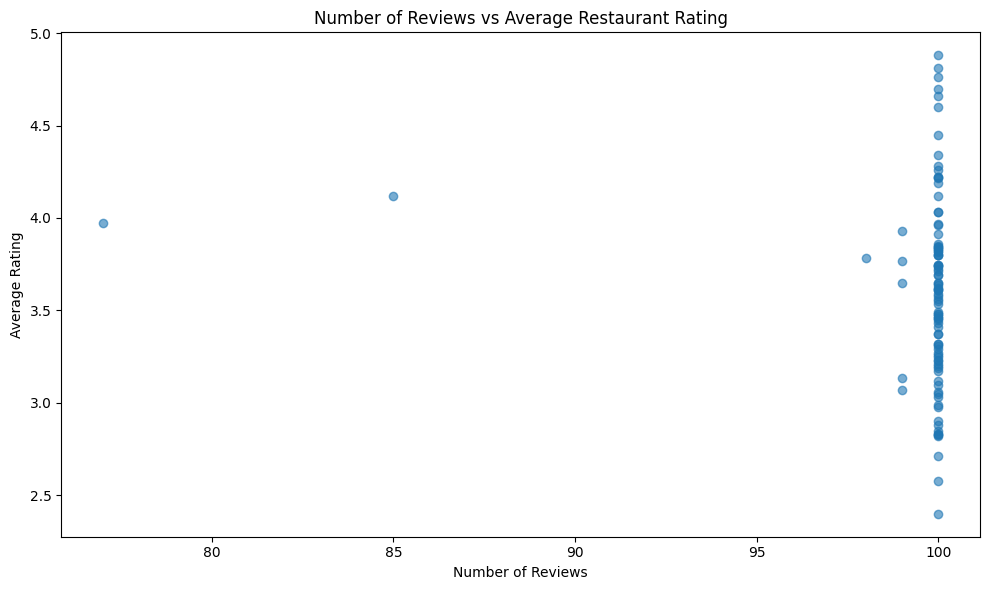

Correlation between Number of Reviews and Average Rating: -0.12

Restaurant-level summary:
                        Restaurant  Average_Rating  Number_of_Reviews
0                10 Downing Street           3.800                100
1                         13 Dhaba           3.480                100
2   3B's - Buddies, Bar & Barbecue           4.760                100
3        AB's - Absolute Barbecues           4.880                100
4                Absolute Sizzlers           3.620                100
11                          B-Dubs           4.810                100
10                  Asian Meal Box           2.580                100
9                     Aromas@11SIX           3.460                100
16                 Beyond Flavours           4.280                100
14                 Behrouz Biryani           2.825                100


In [ ]:
# Chart - 8 visualization code

# Create restaurant-level summary
chart8_df = merged_df.groupby('Restaurant').agg(
    Average_Rating=('Rating_numeric', 'mean'),
    Number_of_Reviews=('Review', 'count')
).reset_index()

# Remove missing values
chart8_df = chart8_df.dropna()

# Scatter plot
plt.figure(figsize=(10, 6))

plt.scatter(
    chart8_df['Number_of_Reviews'],
    chart8_df['Average_Rating'],
    alpha=0.6
)

plt.title('Number of Reviews vs Average Restaurant Rating')
plt.xlabel('Number of Reviews')
plt.ylabel('Average Rating')

plt.tight_layout()
plt.show()

# Calculate correlation
correlation = chart8_df['Number_of_Reviews'].corr(
    chart8_df['Average_Rating']
)

print("Correlation between Number of Reviews and Average Rating:",
      round(correlation, 2))

print("\nRestaurant-level summary:")
print(chart8_df.sort_values('Number_of_Reviews', ascending=False).head(10))

##### 1. Why did you pick the specific chart?

A scatter plot was selected because it is suitable for examining the relationship between two numerical variables: the number of reviews and the average restaurant rating. It helps identify whether restaurants with more reviews tend to receive higher or lower ratings.

##### 2. What is/are the insight(s) found from the chart?

The chart shows a very weak negative relationship between the number of reviews and average restaurant rating, with a correlation of -0.12. Most restaurants have approximately 100 reviews, while their average ratings vary considerably from around 2.4 to 4.9. Therefore, having a higher number of reviews does not necessarily result in a higher restaurant rating.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. The insight suggests that restaurants should focus on improving customer satisfaction and service quality rather than only increasing the number of reviews. A large number of reviews does not guarantee a high rating. Restaurants receiving many reviews but relatively low ratings should analyze customer feedback and improve food quality, service and overall customer experience, as consistently low ratings could negatively affect reputation and future business growth.

#### Chart - 9

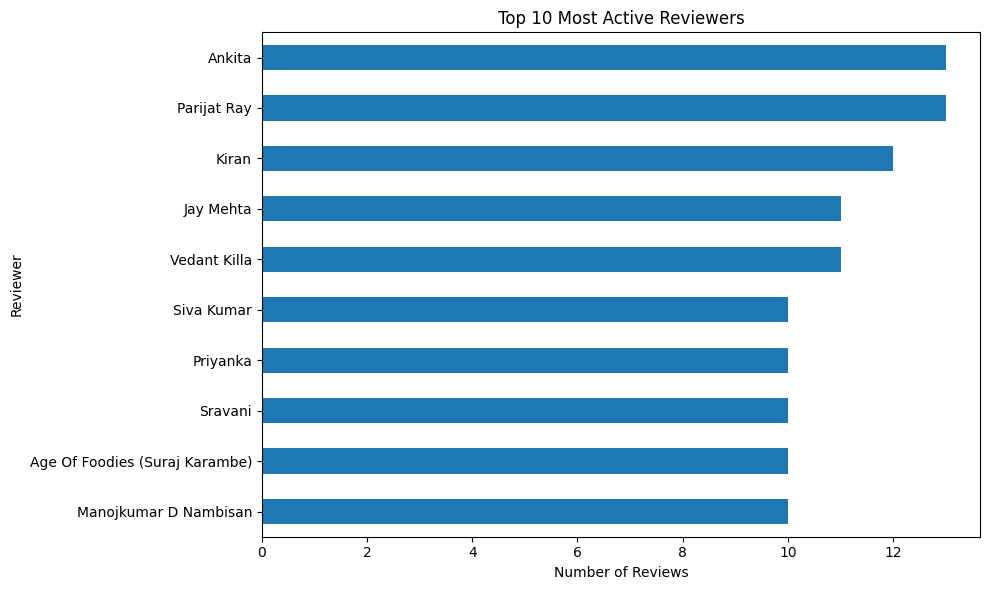

Top 10 Most Active Reviewers:
Reviewer
Ankita                            13
Parijat Ray                       13
Kiran                             12
Vedant Killa                      11
Jay Mehta                         11
Sravani                           10
Manojkumar D Nambisan             10
Age Of Foodies (Suraj Karambe)    10
Priyanka                          10
Siva Kumar                        10
Name: count, dtype: int64


In [ ]:
# Chart - 9 visualization code

# Count reviews written by each reviewer
reviewer_counts = (
    merged_df['Reviewer']
    .dropna()
    .value_counts()
    .head(10)
)

# Plot
plt.figure(figsize=(10, 6))

reviewer_counts.sort_values().plot(kind='barh')

plt.title('Top 10 Most Active Reviewers')
plt.xlabel('Number of Reviews')
plt.ylabel('Reviewer')

plt.tight_layout()
plt.show()

# Display exact values
print("Top 10 Most Active Reviewers:")
print(reviewer_counts)

##### 1. Why did you pick the specific chart?

A horizontal bar chart was selected because it clearly compares the number of reviews contributed by different reviewers. It also makes reviewer names easy to read and helps identify the most active reviewers in the dataset.

##### 2. What is/are the insight(s) found from the chart?

The chart shows that Ankita and Parijat Ray are the most active reviewers, with 13 reviews each, followed by Kiran with 12 reviews. Vedant Killa and Jay Mehta contributed 11 reviews each, while several other top reviewers contributed around 10 reviews. This indicates that a small group of customers is relatively more active in providing restaurant feedback.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. Identifying active reviewers can help businesses understand highly engaged customers and encourage continued customer feedback. Their reviews may provide useful information about food quality, service and overall customer experience. However, relying heavily on a small group of reviewers may create a less representative view of overall customer opinion. Businesses should therefore encourage feedback from a wider range of customers to obtain more balanced insights and support better decision-making.

#### Chart - 10

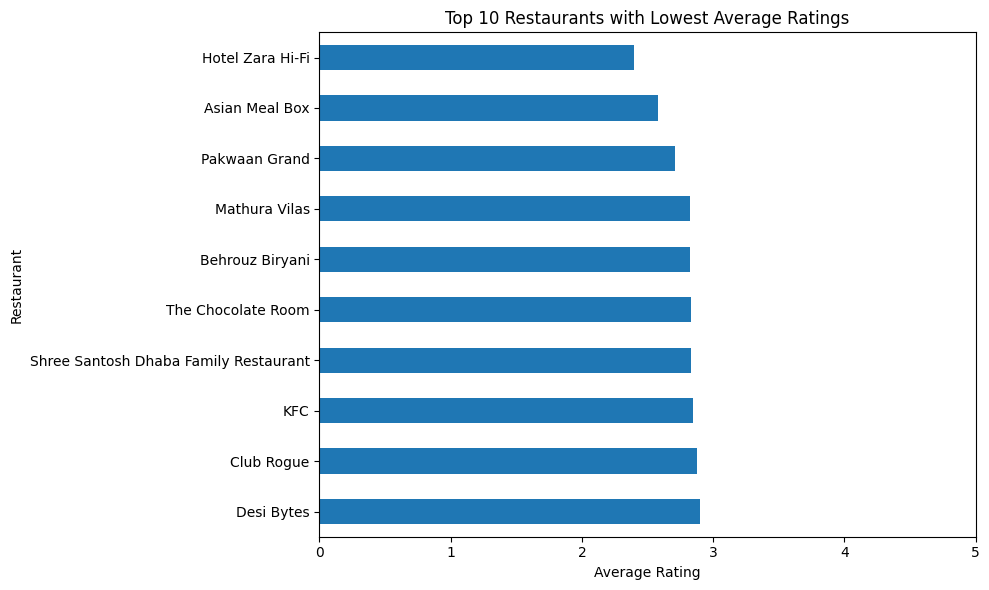

Top 10 Restaurants with Lowest Average Ratings:
Restaurant
Hotel Zara Hi-Fi                         2.40
Asian Meal Box                           2.58
Pakwaan Grand                            2.71
Mathura Vilas                            2.82
Behrouz Biryani                          2.82
Shree Santosh Dhaba Family Restaurant    2.83
The Chocolate Room                       2.83
KFC                                      2.85
Club Rogue                               2.88
Desi Bytes                               2.90
Name: Rating_numeric, dtype: float64


In [ ]:
# Chart - 10 visualization code

# Calculate average rating for each restaurant
lowest_rated = (
    merged_df.groupby('Restaurant')['Rating_numeric']
    .mean()
    .dropna()
    .sort_values()
    .head(10)
)

# Plot
plt.figure(figsize=(10, 6))

lowest_rated.sort_values(ascending=False).plot(kind='barh')

plt.title('Top 10 Restaurants with Lowest Average Ratings')
plt.xlabel('Average Rating')
plt.ylabel('Restaurant')
plt.xlim(0, 5)

plt.tight_layout()
plt.show()

# Display exact values
print("Top 10 Restaurants with Lowest Average Ratings:")
print(lowest_rated.round(2))

##### 1. Why did you pick the specific chart?

A horizontal bar chart was selected because it clearly compares the average ratings of different restaurants. It makes it easy to identify and rank the restaurants with the lowest customer ratings.

##### 2. What is/are the insight(s) found from the chart?

The chart shows that some restaurants have relatively low average customer ratings. Hotel Zara Hi-Fi has the lowest average rating at approximately 2.40, followed by Asian Meal Box at 2.58 and Pakwaan Grand at 2.71. These restaurants may have issues related to food quality, service, pricing, or overall customer experience that require further investigation.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. Identifying the lowest-rated restaurants can help businesses focus on areas requiring improvement. Management can analyze customer reviews and take corrective actions related to food quality, service, pricing, or other customer concerns. Low ratings can negatively affect customer trust, restaurant reputation, and future demand. Therefore, improving the performance of these restaurants could increase customer satisfaction and support positive business growth.

#### Chart - 11

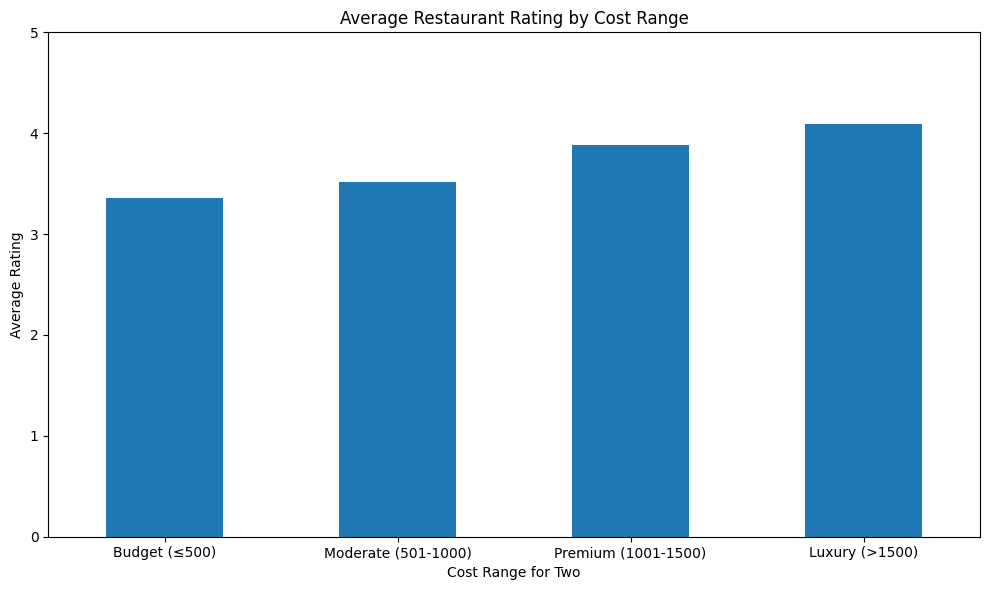

Average Rating by Cost Range:
Cost_Range
Budget (≤500)          3.36
Moderate (501-1000)    3.52
Premium (1001-1500)    3.88
Luxury (>1500)         4.09
Name: Average_Rating, dtype: float64


In [ ]:
# Chart 11 - Average Rating by Cost Range

import pandas as pd
import matplotlib.pyplot as plt

# Select required columns and remove missing values
chart11_df = merged_df[['Restaurant', 'Cost_clean', 'Rating_numeric']].dropna()

# Get one cost value and average rating per restaurant
restaurant_data = chart11_df.groupby('Restaurant').agg(
    Cost=('Cost_clean', 'first'),
    Average_Rating=('Rating_numeric', 'mean')
).reset_index()

# Create cost categories
restaurant_data['Cost_Range'] = pd.cut(
    restaurant_data['Cost'],
    bins=[0, 500, 1000, 1500, float('inf')],
    labels=['Budget (≤500)', 'Moderate (501-1000)',
            'Premium (1001-1500)', 'Luxury (>1500)']
)

# Calculate average rating for each cost category
cost_rating = (
    restaurant_data.groupby('Cost_Range', observed=False)['Average_Rating']
    .mean()
    .dropna()
)

# Plot
plt.figure(figsize=(10, 6))
cost_rating.plot(kind='bar')

plt.title('Average Restaurant Rating by Cost Range')
plt.xlabel('Cost Range for Two')
plt.ylabel('Average Rating')
plt.xticks(rotation=0)
plt.ylim(0, 5)
plt.tight_layout()
plt.show()

# Print results
print("Average Rating by Cost Range:")
print(cost_rating.round(2))

##### 1. Why did you pick the specific chart?

A bar chart was selected because it clearly compares the average restaurant ratings across different cost ranges. It makes it easy to understand how customer ratings vary between budget, moderate, premium, and luxury restaurants.

##### 2. What is/are the insight(s) found from the chart?

The chart shows that average restaurant ratings generally increase with the cost range. Budget restaurants have the lowest average rating at approximately 3.36, while moderate restaurants are around 3.5, premium restaurants around 3.9, and luxury restaurants have the highest average rating at approximately 4.1. This suggests that higher-priced restaurants tend to receive better customer ratings in this dataset.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. This insight can help restaurants understand the relationship between pricing and customer satisfaction. Budget and moderate restaurants can study the service, food quality, ambience, and overall experience offered by higher-rated premium restaurants and improve their own customer experience.

A possible negative impact is that simply increasing prices may not improve ratings. Customers paying higher prices may also have higher expectations. Therefore, restaurants should focus on improving value, quality, and service rather than increasing prices alone.

#### Chart - 12

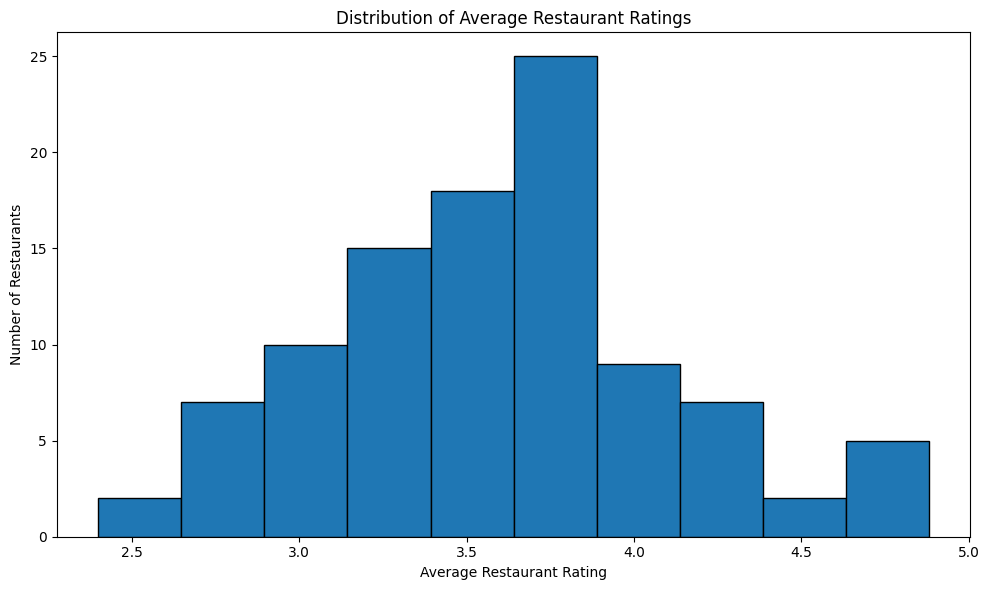

Restaurant Rating Summary:
Minimum Rating: 2.4
Maximum Rating: 4.88
Mean Rating: 3.6
Median Rating: 3.61


In [ ]:
# Chart 12 - Distribution of Average Restaurant Ratings

import pandas as pd
import matplotlib.pyplot as plt

# Prepare restaurant-level average ratings
chart12_df = (
    merged_df[['Restaurant', 'Rating_numeric']]
    .dropna()
    .groupby('Restaurant')['Rating_numeric']
    .mean()
    .reset_index()
)

# Create histogram
plt.figure(figsize=(10, 6))

plt.hist(chart12_df['Rating_numeric'], bins=10, edgecolor='black')

plt.title('Distribution of Average Restaurant Ratings')
plt.xlabel('Average Restaurant Rating')
plt.ylabel('Number of Restaurants')

plt.tight_layout()
plt.show()

# Print summary statistics
print("Restaurant Rating Summary:")
print("Minimum Rating:", round(chart12_df['Rating_numeric'].min(), 2))
print("Maximum Rating:", round(chart12_df['Rating_numeric'].max(), 2))
print("Mean Rating:", round(chart12_df['Rating_numeric'].mean(), 2))
print("Median Rating:", round(chart12_df['Rating_numeric'].median(), 2))

##### 1. Why did you pick the specific chart?

A histogram was selected because it is useful for understanding the distribution of average restaurant ratings. It shows where most restaurant ratings are concentrated and helps identify restaurants with unusually low or high ratings.

##### 2. What is/are the insight(s) found from the chart?

The average restaurant ratings range from 2.40 to 4.88, with a mean of 3.60 and a median of 3.61. Most restaurants are concentrated around the mid-to-high 3 rating range. Since the mean and median are almost equal, the overall distribution is relatively balanced. A smaller number of restaurants have very low ratings below 3 or very high ratings above 4.5.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. The distribution helps identify the general customer satisfaction level and allows restaurants to benchmark their performance against the overall market. Restaurants below the average rating of 3.60 can investigate customer feedback and improve food quality, service, ambience, or value.

Low-rated restaurants, particularly those near the minimum rating of 2.40, may experience negative business growth because poor ratings can reduce customer trust and demand. Improving the factors responsible for negative reviews can increase customer satisfaction and help support business growth.

#### Chart - 13

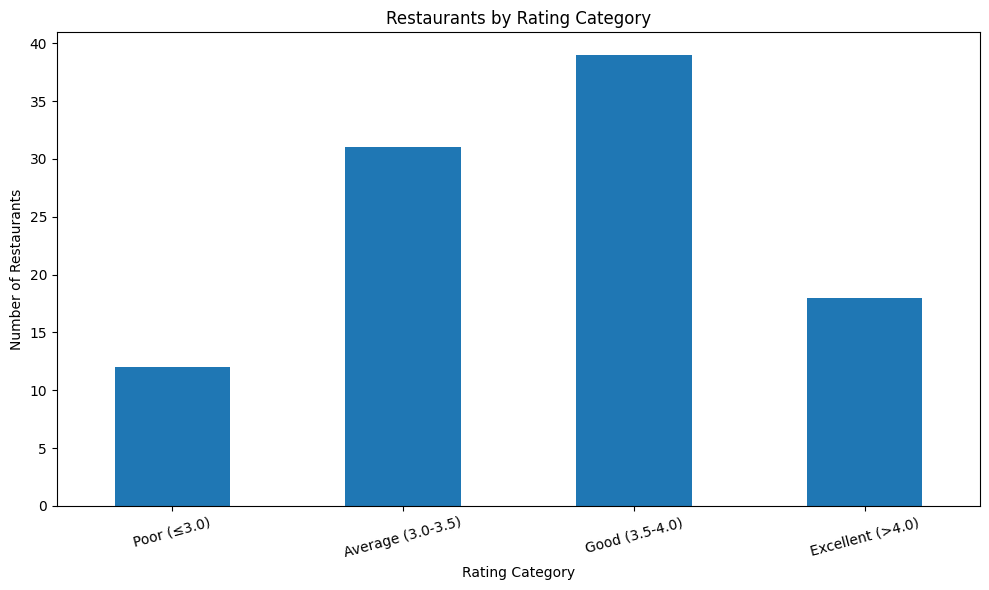

Number of Restaurants by Rating Category:
Rating_Category
Poor (≤3.0)          12
Average (3.0-3.5)    31
Good (3.5-4.0)       39
Excellent (>4.0)     18
Name: count, dtype: int64

Percentage of Restaurants:
Rating_Category
Poor (≤3.0)          12.0
Average (3.0-3.5)    31.0
Good (3.5-4.0)       39.0
Excellent (>4.0)     18.0
Name: count, dtype: float64


In [ ]:
# Chart 13 - Restaurant Rating Categories

import pandas as pd
import matplotlib.pyplot as plt

# Calculate average rating for each restaurant
chart13_df = (
    merged_df[['Restaurant', 'Rating_numeric']]
    .dropna()
    .groupby('Restaurant')['Rating_numeric']
    .mean()
    .reset_index()
)

# Create rating categories
chart13_df['Rating_Category'] = pd.cut(
    chart13_df['Rating_numeric'],
    bins=[0, 3.0, 3.5, 4.0, 5.0],
    labels=[
        'Poor (≤3.0)',
        'Average (3.0-3.5)',
        'Good (3.5-4.0)',
        'Excellent (>4.0)'
    ],
    include_lowest=True
)

# Count restaurants in each category
rating_category_counts = (
    chart13_df['Rating_Category']
    .value_counts(sort=False)
)

# Plot
plt.figure(figsize=(10, 6))

rating_category_counts.plot(kind='bar')

plt.title('Restaurants by Rating Category')
plt.xlabel('Rating Category')
plt.ylabel('Number of Restaurants')
plt.xticks(rotation=15)

plt.tight_layout()
plt.show()

# Print exact values
print("Number of Restaurants by Rating Category:")
print(rating_category_counts)

print("\nPercentage of Restaurants:")
print(
    (rating_category_counts / rating_category_counts.sum() * 100)
    .round(2)
)

##### 1. Why did you pick the specific chart?

A bar chart was selected because it provides a clear comparison of the number of restaurants across different rating categories. It makes it easy to identify which customer satisfaction category contains the largest number of restaurants.

##### 2. What is/are the insight(s) found from the chart?

The chart shows that the largest group is the Good category (3.5–4.0) with 39% of restaurants, followed by the Average category with 31%. Excellent restaurants account for 18%, while only 12% fall into the Poor category. Overall, 57% of restaurants have ratings above 3.5, indicating generally positive customer satisfaction.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. The results help businesses benchmark restaurant performance and identify where improvement is required. The 43% of restaurants rated Average or Poor represent an opportunity to improve food quality, service, ambience, and overall customer experience.

The 12% of restaurants in the Poor category may face negative business growth because low ratings can reduce customer trust, repeat visits, and demand. Moving Average and Poor restaurants into higher rating categories could improve customer satisfaction and business performance.

#### Chart - 14 - Correlation Heatmap

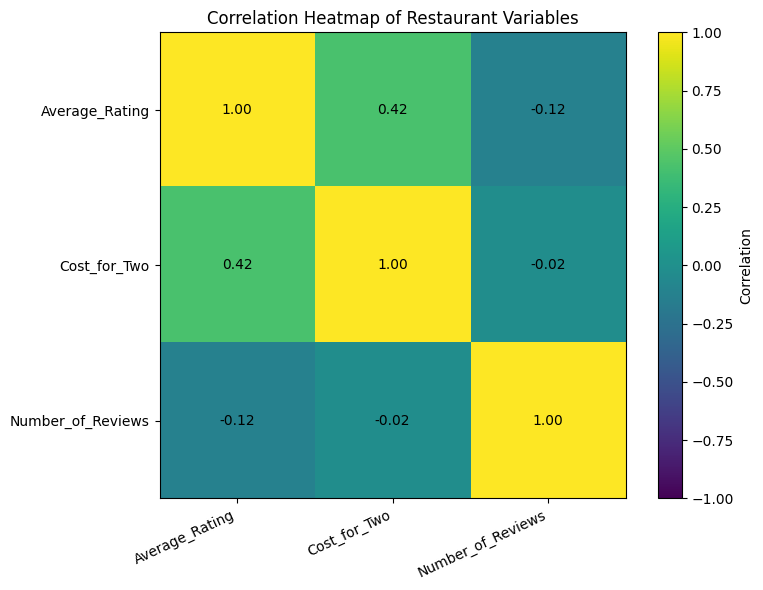

Correlation Matrix:
                   Average_Rating  Cost_for_Two  Number_of_Reviews
Average_Rating               1.00          0.42              -0.12
Cost_for_Two                 0.42          1.00              -0.02
Number_of_Reviews           -0.12         -0.02               1.00


In [ ]:
# Chart 14 - Correlation Heatmap

import pandas as pd
import matplotlib.pyplot as plt

# Prepare restaurant-level numerical data
chart14_df = (
    merged_df.groupby('Restaurant')
    .agg(
        Average_Rating=('Rating_numeric', 'mean'),
        Cost_for_Two=('Cost_clean', 'first'),
        Number_of_Reviews=('Review', 'count')
    )
    .dropna()
)

# Calculate correlation matrix
corr_matrix = chart14_df[
    ['Average_Rating', 'Cost_for_Two', 'Number_of_Reviews']
].corr()

# Create heatmap using matplotlib
fig, ax = plt.subplots(figsize=(8, 6))

heatmap = ax.imshow(corr_matrix, vmin=-1, vmax=1)

# Labels
labels = corr_matrix.columns

ax.set_xticks(range(len(labels)))
ax.set_yticks(range(len(labels)))
ax.set_xticklabels(labels, rotation=25, ha='right')
ax.set_yticklabels(labels)

# Add correlation values inside cells
for i in range(len(labels)):
    for j in range(len(labels)):
        ax.text(
            j, i,
            f'{corr_matrix.iloc[i, j]:.2f}',
            ha='center',
            va='center'
        )

plt.colorbar(heatmap, label='Correlation')
plt.title('Correlation Heatmap of Restaurant Variables')
plt.tight_layout()
plt.show()

print("Correlation Matrix:")
print(corr_matrix.round(2))

##### 1. Why did you pick the specific chart?

A correlation heatmap was selected because it provides a simple visual summary of the relationships between multiple numerical variables at the same time. It helps identify which variables have positive, negative, or weak relationships with each other.

##### 2. What is/are the insight(s) found from the chart?

The heatmap shows that Cost for Two and Average Rating have a moderate positive correlation of 0.42, suggesting that higher-cost restaurants tend to receive somewhat higher ratings. The correlation between Number of Reviews and Average Rating is -0.12, indicating a very weak negative relationship. The correlation between Cost for Two and Number of Reviews is -0.02, which indicates almost no relationship. Therefore, restaurant cost appears to have a stronger relationship with rating than review count does.

#### Chart - 15 - Pair Plot

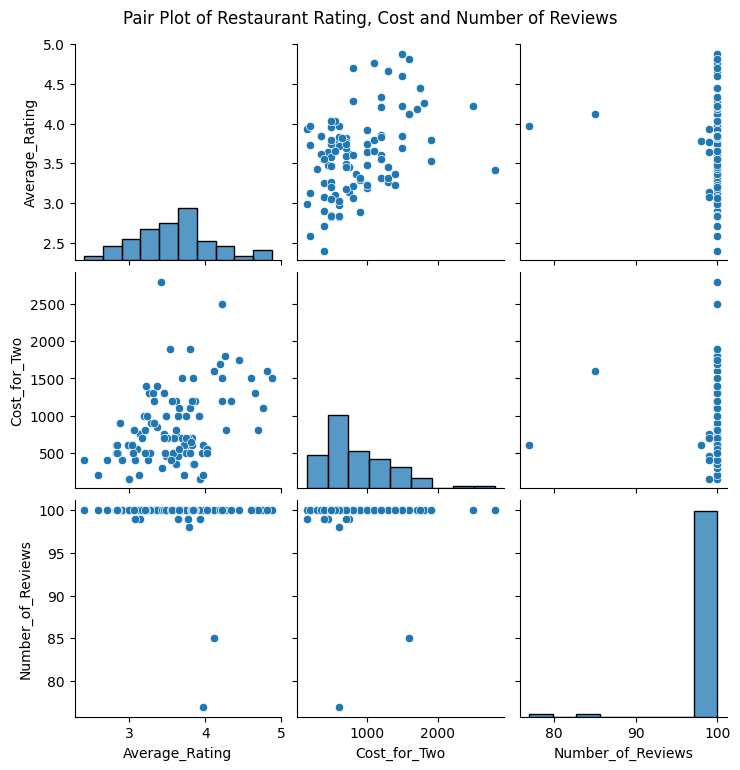

In [ ]:
# Chart - 15 visualization code

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Create restaurant-level dataset from merged_df
pair_data = merged_df.groupby('Restaurant').agg(
    Average_Rating=('Rating_numeric', 'mean'),
    Cost_for_Two=('Cost_clean', 'first'),
    Number_of_Reviews=('Review', 'count')
).reset_index()

# Convert columns to numeric
pair_data['Average_Rating'] = pd.to_numeric(
    pair_data['Average_Rating'], errors='coerce'
)

pair_data['Cost_for_Two'] = pd.to_numeric(
    pair_data['Cost_for_Two'], errors='coerce'
)

pair_data['Number_of_Reviews'] = pd.to_numeric(
    pair_data['Number_of_Reviews'], errors='coerce'
)

# Remove missing values
pair_data = pair_data[
    ['Average_Rating', 'Cost_for_Two', 'Number_of_Reviews']
].dropna()

# Create pair plot
sns.pairplot(pair_data, diag_kind='hist')

plt.suptitle(
    'Pair Plot of Restaurant Rating, Cost and Number of Reviews',
    y=1.02
)

plt.show()

##### 1. Why did you pick the specific chart?

A pair plot was selected because it allows multiple numerical variables to be compared simultaneously. It helps visualize the distributions of individual variables as well as the relationships between Average Rating, Cost for Two, and Number of Reviews.

##### 2. What is/are the insight(s) found from the chart?

The pair plot shows that Cost for Two has a noticeable positive relationship with Average Rating, indicating that higher-priced restaurants tend to receive somewhat higher ratings. In contrast, Number of Reviews shows very little relationship with either Average Rating or Cost for Two. The distributions also show that most restaurants are concentrated around moderate ratings and cost levels.

## ***5. Hypothesis Testing***

### Based on your chart experiments, define three hypothetical statements from the dataset. In the next three questions, perform hypothesis testing to obtain final conclusion about the statements through your code and statistical testing.

hree hypothetical statements were formulated to investigate meaningful relationships within the Zomato restaurant and customer review data. The hypotheses focus on whether customer ratings and sentiment are significantly associated with restaurant/review characteristics. Appropriate statistical hypothesis tests are performed at a 5% significance level (α = 0.05). A p-value below 0.05 will lead to rejection of the null hypothesis, while a p-value greater than or equal to 0.05 will indicate insufficient evidence to reject the null hypothesis.

### Hypothetical Statement - 1

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

Null Hypothesis (H₀): There is no significant relationship between restaurant cost and average rating.

Alternate Hypothesis (H₁): There is a significant positive relationship between restaurant cost and average rating.

#### 2. Perform an appropriate statistical test.

In [ ]:
# Hypothesis Test 1
# Testing relationship between Cost for Two and Average Rating

from scipy.stats import pearsonr

# Prepare restaurant-level data
hyp1_df = (
    merged_df.groupby('Restaurant')
    .agg(
        Average_Rating=('Rating_numeric', 'mean'),
        Cost_for_Two=('Cost_clean', 'first')
    )
    .dropna()
)

# Pearson correlation test
corr, p_value = pearsonr(
    hyp1_df['Cost_for_Two'],
    hyp1_df['Average_Rating']
)

print("Pearson Correlation:", round(corr, 3))
print("P-value:", round(p_value, 5))

# Decision
alpha = 0.05

if p_value < alpha:
    print("Result: Reject the Null Hypothesis")
    print("Conclusion: There is a statistically significant relationship between restaurant cost and average rating.")
else:
    print("Result: Fail to Reject the Null Hypothesis")
    print("Conclusion: There is no statistically significant relationship between restaurant cost and average rating.")

Pearson Correlation: 0.422
P-value: 1e-05
Result: Reject the Null Hypothesis
Conclusion: There is a statistically significant relationship between restaurant cost and average rating.


##### Which statistical test have you done to obtain P-Value?

Pearson Correlation Test was used to obtain the p-value.

##### Why did you choose the specific statistical test?

Pearson Correlation Test was chosen because both Cost for Two and Average Rating are numerical variables, and the objective is to determine whether there is a statistically significant linear relationship between them.

### Hypothetical Statement - 2

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

Null Hypothesis (H₀): There is no significant relationship between the number of reviews a restaurant receives and its average rating.

Alternate Hypothesis (H₁): There is a significant relationship between the number of reviews a restaurant receives and its average rating.

#### 2. Perform an appropriate statistical test.

In [ ]:
from scipy.stats import pearsonr

# Create restaurant-level data directly from merged_df
hypothesis2_data = (
    merged_df.groupby('Restaurant')
    .agg(
        Average_Rating=('Rating_numeric', 'mean'),
        Number_of_Reviews=('Review', 'count')
    )
    .reset_index()
    .dropna()
)

# Pearson correlation test
corr, p_value = pearsonr(
    hypothesis2_data['Number_of_Reviews'],
    hypothesis2_data['Average_Rating']
)

print("Pearson Correlation:", round(corr, 3))
print("P-value:", round(p_value, 5))

alpha = 0.05

if p_value < alpha:
    print("Result: Reject the Null Hypothesis")
    print("Conclusion: There is a statistically significant relationship between number of reviews and average rating.")
else:
    print("Result: Fail to Reject the Null Hypothesis")
    print("Conclusion: There is no statistically significant relationship between number of reviews and average rating.")

Pearson Correlation: -0.118
P-value: 0.24388
Result: Fail to Reject the Null Hypothesis
Conclusion: There is no statistically significant relationship between number of reviews and average rating.


##### Which statistical test have you done to obtain P-Value?

Pearson Correlation Test.

##### Why did you choose the specific statistical test?

The Pearson Correlation Test was chosen because both Number of Reviews and Average Rating are numerical variables, and the test helps determine whether there is a statistically significant linear relationship between them.

### Hypothetical Statement - 3

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

Null Hypothesis (H₀): The mean restaurant rating is the same across all cost categories.

Alternate Hypothesis (H₁): At least one cost category has a significantly different mean restaurant rating.

#### 2. Perform an appropriate statistical test.

In [ ]:
from scipy.stats import f_oneway
import pandas as pd

# Create restaurant-level dataset
hypothesis3_data = (
    merged_df.groupby('Restaurant')
    .agg(
        Average_Rating=('Rating_numeric', 'mean'),
        Cost_for_Two=('Cost_clean', 'first')
    )
    .reset_index()
    .dropna()
)

# Create cost categories
hypothesis3_data['Cost_Category'] = pd.cut(
    hypothesis3_data['Cost_for_Two'],
    bins=[0, 500, 1000, 1500, float('inf')],
    labels=['Budget', 'Moderate', 'Premium', 'Luxury']
)

# Separate ratings for each cost category
budget = hypothesis3_data[
    hypothesis3_data['Cost_Category'] == 'Budget'
]['Average_Rating']

moderate = hypothesis3_data[
    hypothesis3_data['Cost_Category'] == 'Moderate'
]['Average_Rating']

premium = hypothesis3_data[
    hypothesis3_data['Cost_Category'] == 'Premium'
]['Average_Rating']

luxury = hypothesis3_data[
    hypothesis3_data['Cost_Category'] == 'Luxury'
]['Average_Rating']

# One-Way ANOVA
f_stat, p_value = f_oneway(budget, moderate, premium, luxury)

print("F-statistic:", round(f_stat, 3))
print("P-value:", round(p_value, 5))

alpha = 0.05

if p_value < alpha:
    print("Result: Reject the Null Hypothesis")
    print("Conclusion: Average ratings differ significantly across cost categories.")
else:
    print("Result: Fail to Reject the Null Hypothesis")
    print("Conclusion: Average ratings do not differ significantly across cost categories.")

F-statistic: 10.055
P-value: 1e-05
Result: Reject the Null Hypothesis
Conclusion: Average ratings differ significantly across cost categories.


##### Which statistical test have you done to obtain P-Value?

One-Way ANOVA (Analysis of Variance).

##### Why did you choose the specific statistical test?

One-Way ANOVA was chosen because it allows us to compare the mean restaurant ratings across more than two independent cost categories and determine whether the differences are statistically significant.

## ***6. Feature Engineering & Data Pre-processing***

### 1. Handling Missing Values

In [ ]:
# Handling Missing Values & Missing Value Imputation

print("Missing values before handling:")
print(reviews_data.isnull().sum())

# Remove rows where essential review information is missing
reviews_data = reviews_data.dropna(
    subset=['Reviewer', 'Review', 'Rating', 'Metadata', 'Time']
).copy()

print("\nMissing values after handling:")
print(reviews_data.isnull().sum())

print("\nDataset shape after handling missing values:")
print(reviews_data.shape)

Missing values before handling:
Restaurant              0
Reviewer                0
Review                  0
Rating                  0
Metadata                0
Time                    0
Pictures                0
Cleaned_Review          0
Final_Cleaned_Review    0
Tokens                  0
Lemmatized_Tokens       0
Normalized_Review       0
POS_Tags                0
Review_Length           0
Word_Count              0
Rating_Numeric          0
Sentiment               0
Review_Length_Scaled    0
Word_Count_Scaled       0
dtype: int64

Missing values after handling:
Restaurant              0
Reviewer                0
Review                  0
Rating                  0
Metadata                0
Time                    0
Pictures                0
Cleaned_Review          0
Final_Cleaned_Review    0
Tokens                  0
Lemmatized_Tokens       0
Normalized_Review       0
POS_Tags                0
Review_Length           0
Word_Count              0
Rating_Numeric          0
Sentiment    

#### What all missing value imputation techniques have you used and why did you use those techniques?

Missing values were identified in the Reviewer, Review, Rating, Metadata and Time columns. Since the number of missing records was very small compared to the overall dataset of 10,000 reviews, row deletion was used instead of statistical imputation. These fields contain important review-specific information, and imputing artificial values, especially for review text and ratings, could introduce bias into the analysis. The restaurant-level dataset contained no missing values and therefore required no missing-value treatment.

### 2. Handling Outliers

In [ ]:
# Handling Outliers & Outlier Treatments

# Check outliers using the IQR method
for column in ['Cost', 'Average_Rating']:
    Q1 = restaurant_data[column].quantile(0.25)
    Q3 = restaurant_data[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = restaurant_data[
        (restaurant_data[column] < lower_bound) |
        (restaurant_data[column] > upper_bound)
    ]

    print(f"\n{column}")
    print("Lower Bound:", round(lower_bound, 2))
    print("Upper Bound:", round(upper_bound, 2))
    print("Number of Outliers:", len(outliers))

# Remove outliers using the IQR method
for column in ['Cost', 'Average_Rating']:
    Q1 = restaurant_data[column].quantile(0.25)
    Q3 = restaurant_data[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    restaurant_data = restaurant_data[
        (restaurant_data[column] >= lower_bound) &
        (restaurant_data[column] <= upper_bound)
    ]

print("Dataset shape after outlier treatment:", restaurant_data.shape)


Cost
Lower Bound: -550.0
Upper Bound: 2250.0
Number of Outliers: 2

Average_Rating
Lower Bound: 2.34
Upper Bound: 4.75
Number of Outliers: 3
Dataset shape after outlier treatment: (96, 4)


##### What all outlier treatment techniques have you used and why did you use those techniques?

I used the IQR (Interquartile Range) method to detect outliers in the Cost and Average_Rating variables. Values below Q1 − 1.5×IQR or above Q3 + 1.5×IQR were considered outliers. Since only a small number of outliers were detected, they were removed to reduce their potential influence on further analysis and model performance.

### 3. Categorical Encoding

In [ ]:
# Encode categorical column Cost_Range using One-Hot Encoding

print("Cost Range categories:")
print(restaurant_data['Cost_Range'].value_counts())

restaurant_data = pd.get_dummies(
    restaurant_data,
    columns=['Cost_Range'],
    prefix='Cost_Range',
    drop_first=True,
    dtype=int
)

print("\nDataset after categorical encoding:")
print(restaurant_data.head())

print("\nNew columns:")
print(restaurant_data.columns.tolist())

Cost Range categories:
Cost_Range
Moderate (501-1000)    39
Budget (≤500)          30
Premium (1001-1500)    20
Luxury (>1500)          7
Name: count, dtype: int64

Dataset after categorical encoding:
                       Restaurant  Cost  Average_Rating  \
0               10 Downing Street  1900        3.800000   
1                        13 Dhaba   450        3.480000   
2  3B's - Buddies, Bar & Barbecue  1100        4.760000   
4               Absolute Sizzlers   750        3.620000   
5              Al Saba Restaurant   750        3.136364   

   Cost_Range_Moderate (501-1000)  Cost_Range_Premium (1001-1500)  \
0                               0                               0   
1                               0                               0   
2                               0                               1   
4                               1                               0   
5                               1                               0   

   Cost_Range_Luxury (>1500) 

#### What all categorical encoding techniques have you used & why did you use those techniques?

One-Hot Encoding was used for the Cost_Range categorical variable. This technique converts categorical values into separate binary numerical features without introducing an artificial ordinal relationship between the categories. The Restaurant column was not encoded because it represents restaurant names/identifiers rather than a meaningful categorical predictor.

### 4. Textual Data Preprocessing
(It's mandatory for textual dataset i.e., NLP, Sentiment Analysis, Text Clustering etc.)

#### 1. Expand Contraction

In [ ]:
# Expand common contractions in review text
import re

contractions = {
    "can't": "cannot",
    "won't": "will not",
    "n't": " not",
    "'re": " are",
    "'s": " is",
    "'d": " would",
    "'ll": " will",
    "'ve": " have",
    "'m": " am"
}

def expand_contractions(text):
    text = str(text)
    for contraction, expanded in contractions.items():
        text = text.replace(contraction, expanded)
    return text

reviews_data['Cleaned_Review'] = reviews_data['Review'].apply(expand_contractions)

print(reviews_data[['Review', 'Cleaned_Review']].head())

                                              Review  \
0  The ambience was good, food was quite good . h...   
1  Ambience is too good for a pleasant evening. S...   
2  A must try.. great food great ambience. Thnx f...   
3  Soumen das and Arun was a great guy. Only beca...   
4  Food is good.we ordered Kodi drumsticks and ba...   

                                      Cleaned_Review  
0  The ambience was good, food was quite good . h...  
1  Ambience is too good for a pleasant evening. S...  
2  A must try.. great food great ambience. Thnx f...  
3  Soumen das and Arun was a great guy. Only beca...  
4  Food is good.we ordered Kodi drumsticks and ba...  


#### 2. Lower Casing

In [ ]:
# Convert cleaned reviews to lowercase
reviews_data['Cleaned_Review'] = reviews_data['Cleaned_Review'].str.lower()

# Display sample
print(reviews_data[['Review', 'Cleaned_Review']].head())

                                              Review  \
0  The ambience was good, food was quite good . h...   
1  Ambience is too good for a pleasant evening. S...   
2  A must try.. great food great ambience. Thnx f...   
3  Soumen das and Arun was a great guy. Only beca...   
4  Food is good.we ordered Kodi drumsticks and ba...   

                                      Cleaned_Review  
0  the ambience was good, food was quite good . h...  
1  ambience is too good for a pleasant evening. s...  
2  a must try.. great food great ambience. thnx f...  
3  soumen das and arun was a great guy. only beca...  
4  food is good.we ordered kodi drumsticks and ba...  


#### 3. Removing Punctuations

In [ ]:
# Remove punctuation from cleaned reviews
import string

reviews_data['Cleaned_Review'] = reviews_data['Cleaned_Review'].apply(
    lambda text: text.translate(str.maketrans('', '', string.punctuation))
)

# Display sample after punctuation removal
print(reviews_data[['Review', 'Cleaned_Review']].head())

                                              Review  \
0  The ambience was good, food was quite good . h...   
1  Ambience is too good for a pleasant evening. S...   
2  A must try.. great food great ambience. Thnx f...   
3  Soumen das and Arun was a great guy. Only beca...   
4  Food is good.we ordered Kodi drumsticks and ba...   

                                      Cleaned_Review  
0  the ambience was good food was quite good  had...  
1  ambience is too good for a pleasant evening se...  
2  a must try great food great ambience thnx for ...  
3  soumen das and arun was a great guy only becau...  
4  food is goodwe ordered kodi drumsticks and bas...  


#### 4. Removing URLs & Removing words and digits contain digits.

In [ ]:
# Remove URLs and words containing digits
import re

def remove_urls_digits(text):
    # Remove URLs
    text = re.sub(r'http\S+|www\.\S+', '', text)

    # Remove words containing numbers/digits
    text = re.sub(r'\b\w*\d\w*\b', '', text)

    return text

reviews_data['Cleaned_Review'] = reviews_data['Cleaned_Review'].apply(remove_urls_digits)

# Display sample
print(reviews_data[['Review', 'Cleaned_Review']].head())

                                              Review  \
0  The ambience was good, food was quite good . h...   
1  Ambience is too good for a pleasant evening. S...   
2  A must try.. great food great ambience. Thnx f...   
3  Soumen das and Arun was a great guy. Only beca...   
4  Food is good.we ordered Kodi drumsticks and ba...   

                                      Cleaned_Review  
0  the ambience was good food was quite good  had...  
1  ambience is too good for a pleasant evening se...  
2  a must try great food great ambience thnx for ...  
3  soumen das and arun was a great guy only becau...  
4  food is goodwe ordered kodi drumsticks and bas...  


#### 5. Removing Stopwords & Removing White spaces

In [ ]:
# Remove URLs and words containing digits
import re

def remove_urls_digits(text):
    # Remove URLs
    text = re.sub(r'http\S+|www\.\S+', '', text)

    # Remove words containing numbers/digits
    text = re.sub(r'\b\w*\d\w*\b', '', text)

    return text

reviews_data['Cleaned_Review'] = reviews_data['Cleaned_Review'].apply(remove_urls_digits)

# Display sample
print(reviews_data[['Review', 'Cleaned_Review']].head())

                                              Review  \
0  The ambience was good, food was quite good . h...   
1  Ambience is too good for a pleasant evening. S...   
2  A must try.. great food great ambience. Thnx f...   
3  Soumen das and Arun was a great guy. Only beca...   
4  Food is good.we ordered Kodi drumsticks and ba...   

                                      Cleaned_Review  
0  the ambience was good food was quite good  had...  
1  ambience is too good for a pleasant evening se...  
2  a must try great food great ambience thnx for ...  
3  soumen das and arun was a great guy only becau...  
4  food is goodwe ordered kodi drumsticks and bas...  


In [ ]:
# Remove extra white spaces

reviews_data['Cleaned_Review'] = (
    reviews_data['Cleaned_Review']
    .str.replace(r'\s+', ' ', regex=True)
    .str.strip()
)

print(reviews_data[['Review', 'Cleaned_Review']].head())

                                              Review  \
0  The ambience was good, food was quite good . h...   
1  Ambience is too good for a pleasant evening. S...   
2  A must try.. great food great ambience. Thnx f...   
3  Soumen das and Arun was a great guy. Only beca...   
4  Food is good.we ordered Kodi drumsticks and ba...   

                                      Cleaned_Review  
0  the ambience was good food was quite good had ...  
1  ambience is too good for a pleasant evening se...  
2  a must try great food great ambience thnx for ...  
3  soumen das and arun was a great guy only becau...  
4  food is goodwe ordered kodi drumsticks and bas...  


#### 6. Rephrase Text

In [ ]:
# Rephrasing is intentionally not applied.
# For sentiment analysis, preserving the original meaning and sentiment
# of customer reviews is important.

reviews_data['Final_Cleaned_Review'] = reviews_data['Cleaned_Review'].copy()

# Display final cleaned reviews
print(
    reviews_data[
        ['Review', 'Final_Cleaned_Review']
    ].head()
)

                                              Review  \
0  The ambience was good, food was quite good . h...   
1  Ambience is too good for a pleasant evening. S...   
2  A must try.. great food great ambience. Thnx f...   
3  Soumen das and Arun was a great guy. Only beca...   
4  Food is good.we ordered Kodi drumsticks and ba...   

                                Final_Cleaned_Review  
0  the ambience was good food was quite good had ...  
1  ambience is too good for a pleasant evening se...  
2  a must try great food great ambience thnx for ...  
3  soumen das and arun was a great guy only becau...  
4  food is goodwe ordered kodi drumsticks and bas...  


#### 7. Tokenization

In [ ]:
# Tokenization of cleaned reviews
import nltk
from nltk.tokenize import word_tokenize

nltk.download('punkt')
nltk.download('punkt_tab')

# Convert each cleaned review into individual word tokens
reviews_data['Tokens'] = reviews_data['Final_Cleaned_Review'].apply(
    word_tokenize
)

# Display tokenized reviews
print(
    reviews_data[
        ['Final_Cleaned_Review', 'Tokens']
    ].head()
)

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


                                Final_Cleaned_Review  \
0  the ambience was good food was quite good had ...   
1  ambience is too good for a pleasant evening se...   
2  a must try great food great ambience thnx for ...   
3  soumen das and arun was a great guy only becau...   
4  food is goodwe ordered kodi drumsticks and bas...   

                                              Tokens  
0  [the, ambience, was, good, food, was, quite, g...  
1  [ambience, is, too, good, for, a, pleasant, ev...  
2  [a, must, try, great, food, great, ambience, t...  
3  [soumen, das, and, arun, was, a, great, guy, o...  
4  [food, is, goodwe, ordered, kodi, drumsticks, ...  


#### 8. Text Normalization

In [ ]:
# Text Normalization using Lemmatization

import nltk
from nltk.stem import WordNetLemmatizer

# Download required NLTK resources
nltk.download('wordnet')
nltk.download('omw-1.4')

lemmatizer = WordNetLemmatizer()

# Lemmatize tokenized reviews
reviews_data['Lemmatized_Tokens'] = reviews_data['Tokens'].apply(
    lambda tokens: [lemmatizer.lemmatize(word) for word in tokens]
)

# Convert tokens back into cleaned text
reviews_data['Normalized_Review'] = reviews_data['Lemmatized_Tokens'].apply(
    lambda tokens: ' '.join(tokens)
)

# Display results
print(
    reviews_data[
        ['Final_Cleaned_Review', 'Normalized_Review']
    ].head()
)

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


                                Final_Cleaned_Review  \
0  the ambience was good food was quite good had ...   
1  ambience is too good for a pleasant evening se...   
2  a must try great food great ambience thnx for ...   
3  soumen das and arun was a great guy only becau...   
4  food is goodwe ordered kodi drumsticks and bas...   

                                   Normalized_Review  
0  the ambience wa good food wa quite good had sa...  
1  ambience is too good for a pleasant evening se...  
2  a must try great food great ambience thnx for ...  
3  soumen da and arun wa a great guy only because...  
4  food is goodwe ordered kodi drumstick and bask...  


##### Which text normalization technique have you used and why?

Lemmatization was used for text normalization. It reduces words to their meaningful base or dictionary form while preserving their linguistic meaning. This helps reduce vocabulary size and improves consistency in the review text, making it more suitable for sentiment analysis and text vectorization.

#### 9. Part of speech tagging

In [ ]:
# Part of Speech (POS) Tagging

import nltk
from nltk import pos_tag

# Download required POS tagger resources
nltk.download('averaged_perceptron_tagger')
nltk.download('averaged_perceptron_tagger_eng')

# Apply POS tagging on tokenized reviews
reviews_data['POS_Tags'] = reviews_data['Tokens'].apply(pos_tag)

# Display sample
print(
    reviews_data[
        ['Tokens', 'POS_Tags']
    ].head()
)

[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!


                                              Tokens  \
0  [the, ambience, was, good, food, was, quite, g...   
1  [ambience, is, too, good, for, a, pleasant, ev...   
2  [a, must, try, great, food, great, ambience, t...   
3  [soumen, das, and, arun, was, a, great, guy, o...   
4  [food, is, goodwe, ordered, kodi, drumsticks, ...   

                                            POS_Tags  
0  [(the, DT), (ambience, NN), (was, VBD), (good,...  
1  [(ambience, NN), (is, VBZ), (too, RB), (good, ...  
2  [(a, DT), (must, MD), (try, VB), (great, JJ), ...  
3  [(soumen, NNS), (das, NNS), (and, CC), (arun, ...  
4  [(food, NN), (is, VBZ), (goodwe, JJ), (ordered...  


#### 10. Text Vectorization

In [ ]:
# Text Vectorization using TF-IDF

from sklearn.feature_extraction.text import TfidfVectorizer

# Initialize TF-IDF Vectorizer
tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2)
)

# Convert normalized review text into numerical features
X_tfidf = tfidf.fit_transform(
    reviews_data['Normalized_Review']
)

# Display vectorized data information
print("TF-IDF Matrix Shape:", X_tfidf.shape)
print("Number of Features:", len(tfidf.get_feature_names_out()))

# Display some sample feature names
print("\nSample Features:")
print(tfidf.get_feature_names_out()[:30])

TF-IDF Matrix Shape: (9954, 5000)
Number of Features: 5000

Sample Features:
['ab' 'able' 'able to' 'about' 'about food' 'about it' 'about the'
 'about their' 'about this' 'above' 'above average' 'absolute'
 'absolutely' 'absolutely delicious' 'absolutely loved' 'ac' 'accept'
 'accepted' 'accompanied' 'according' 'according to' 'achari' 'across'
 'actually' 'add' 'add on' 'add to' 'added' 'adding' 'addition']


##### Which text vectorization technique have you used and why?

TF-IDF (Term Frequency–Inverse Document Frequency) vectorization was used to convert the cleaned textual reviews into numerical features. TF-IDF assigns higher importance to informative words while reducing the influence of very common words. Unigrams and bigrams were considered so that both individual words and short phrases can contribute to sentiment prediction. This representation is suitable for machine learning models working with textual review data.

### 4. Feature Manipulation & Selection

#### 1. Feature Manipulation

In [ ]:
# Feature Manipulation - Create useful features from review text

# Number of characters in each cleaned review
reviews_data['Review_Length'] = reviews_data['Normalized_Review'].str.len()

# Number of words in each cleaned review
reviews_data['Word_Count'] = reviews_data['Normalized_Review'].apply(
    lambda text: len(text.split())
)

print("Newly created features:")
print(
    reviews_data[
        ['Normalized_Review', 'Review_Length', 'Word_Count']
    ].head()
)

print("\nSummary:")
print(reviews_data[['Review_Length', 'Word_Count']].describe())

Newly created features:
                                   Normalized_Review  Review_Length  \
0  the ambience wa good food wa quite good had sa...            205   
1  ambience is too good for a pleasant evening se...            137   
2  a must try great food great ambience thnx for ...            174   
3  soumen da and arun wa a great guy only because...            142   
4  food is goodwe ordered kodi drumstick and bask...            152   

   Word_Count  
0          38  
1          26  
2          30  
3          28  
4          27  

Summary:
       Review_Length   Word_Count
count    9954.000000  9954.000000
mean      265.491059    49.649086
std       321.236444    60.127469
min         0.000000     0.000000
25%       137.000000    24.000000
50%       180.000000    34.000000
75%       306.000000    57.000000
max      5049.000000   972.000000


#### 2. Feature Selection

In [ ]:
# Convert Rating to numeric
# Invalid values such as "Like" will become NaN
reviews_data['Rating_Numeric'] = pd.to_numeric(
    reviews_data['Rating'],
    errors='coerce'
)

# Remove rows containing invalid ratings
reviews_data = reviews_data.dropna(
    subset=['Rating_Numeric']
).copy()

# Create sentiment target:
# 1 = Positive (Rating >= 4)
# 0 = Negative (Rating < 4)
reviews_data['Sentiment'] = (
    reviews_data['Rating_Numeric'] >= 4
).astype(int)

print("Sentiment distribution:")
print(reviews_data['Sentiment'].value_counts())

print("\nSentiment percentage:")
print(
    reviews_data['Sentiment']
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

# Select features for sentiment classification

# Text feature
text_feature = reviews_data['Normalized_Review']

# Additional engineered numerical features
numerical_features = reviews_data[
    ['Review_Length', 'Word_Count']
]

# Target variable
target = reviews_data['Sentiment']

print("Selected text feature: Normalized_Review")
print("Selected numerical features: Review_Length, Word_Count")
print("Target variable: Sentiment")

print("\nDataset shape:", reviews_data.shape)
print("Target shape:", target.shape)

Sentiment distribution:
Sentiment
1    6268
0    3686
Name: count, dtype: int64

Sentiment percentage:
Sentiment
1    62.97
0    37.03
Name: proportion, dtype: float64
Selected text feature: Normalized_Review
Selected numerical features: Review_Length, Word_Count
Target variable: Sentiment

Dataset shape: (9954, 19)
Target shape: (9954,)


##### What all feature selection methods have you used  and why?

Feature selection was performed using domain knowledge and relevance-based selection. Normalized_Review was selected as the primary feature because the words used by customers directly contain sentiment information. Additionally, Review_Length and Word_Count were retained as engineered numerical features because review length may capture customer engagement or intensity of opinion. Irrelevant/high-cardinality identification fields such as reviewer name and restaurant name were not used directly for sentiment prediction, helping reduce unnecessary dimensionality and the risk of overfitting.

##### Which all features you found important and why?

The most important feature is Normalized_Review, as textual content directly expresses customer opinions regarding food, service, ambience and overall experience. Review_Length and Word_Count were also considered useful supporting features because the amount of text written may reflect the customer's level of engagement or strength of opinion. Rating_Numeric was used to construct the target variable and therefore was not included as an input feature, avoiding target leakage.

### 5. Data Transformation

#### Do you think that your data needs to be transformed? If yes, which transformation have you used. Explain Why?

Yes. The textual data required transformation because machine learning algorithms cannot directly process raw text. The review text was cleaned and normalized using lowercasing, punctuation removal, URL/digit removal, stopword removal and lemmatization. After normalization, TF-IDF vectorization was used to transform the textual reviews into numerical feature vectors. TF-IDF was selected because it gives higher importance to informative words while reducing the influence of very frequently occurring words. No additional logarithmic or power transformation was required because the primary feature is textual data rather than a continuous skewed numerical variable.

### 6. Data Scaling

In [ ]:
from sklearn.preprocessing import StandardScaler

# Numerical features to be scaled
numerical_cols = ['Review_Length', 'Word_Count']

# Initialize StandardScaler
scaler = StandardScaler()

# Create scaled versions of numerical features
reviews_data[['Review_Length_Scaled', 'Word_Count_Scaled']] = (
    scaler.fit_transform(reviews_data[numerical_cols])
)

print("Data before scaling:")
print(reviews_data[numerical_cols].head())

print("\nData after scaling:")
print(
    reviews_data[
        ['Review_Length_Scaled', 'Word_Count_Scaled']
    ].head()
)

print("\nScaled feature summary:")
print(
    reviews_data[
        ['Review_Length_Scaled', 'Word_Count_Scaled']
    ].describe().round(3)
)

Data before scaling:
   Review_Length  Word_Count
0            205          38
1            137          26
2            174          30
3            142          28
4            152          27

Data after scaling:
   Review_Length_Scaled  Word_Count_Scaled
0             -0.188316          -0.193750
1             -0.400009          -0.393336
2             -0.284823          -0.326807
3             -0.384443          -0.360071
4             -0.353312          -0.376703

Scaled feature summary:
       Review_Length_Scaled  Word_Count_Scaled
count              9954.000           9954.000
mean                 -0.000              0.000
std                   1.000              1.000
min                  -0.827             -0.826
25%                  -0.400             -0.427
50%                  -0.266             -0.260
75%                   0.126              0.122
max                  14.892             15.341


##### Which method have you used to scale you data and why?

StandardScaler was used to scale the numerical features Review_Length and Word_Count. Standardization transforms the features so that they have approximately zero mean and unit variance. This prevents features with larger numerical ranges from having disproportionate influence on machine learning algorithms. TF-IDF features were not standardized separately because TF-IDF already produces normalized numerical representations, and unnecessary scaling can reduce the efficiency of sparse text features.

### 7. Dimesionality Reduction

##### Do you think that dimensionality reduction is needed? Explain Why?

No separate dimensionality reduction technique was considered necessary for this project. The main text feature is represented using TF-IDF, which produces a sparse feature matrix. The dimensionality of the text representation is already controlled through TF-IDF parameters such as maximum feature count and document-frequency thresholds. Applying additional dimensionality reduction could remove informative words that are useful for sentiment classification. Therefore, the original TF-IDF representation was retained for model training.

In [ ]:
# Dimensionality Reduction

# No additional dimensionality reduction is applied.
# TF-IDF feature space is already controlled using max_features.

print("TF-IDF matrix shape:", X_tfidf.shape)
print("Number of TF-IDF features:", X_tfidf.shape[1])

print("\nNo additional dimensionality reduction applied.")
print("TF-IDF sparse representation will be retained for modelling.")

TF-IDF matrix shape: (9954, 5000)
Number of TF-IDF features: 5000

No additional dimensionality reduction applied.
TF-IDF sparse representation will be retained for modelling.


##### Which dimensionality reduction technique have you used and why? (If dimensionality reduction done on dataset.)

TF-IDF (Term Frequency–Inverse Document Frequency) vectorization was used to convert the cleaned textual reviews into numerical features. TF-IDF assigns higher importance to informative words while reducing the influence of very common words. Unigrams and bigrams were considered so that both individual words and short phrases can contribute to sentiment prediction. This representation is suitable for machine learning models working with textual review data.

### 8. Data Splitting

In [ ]:
# Split data into training and testing sets

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

# Input text and target
X = reviews_data['Normalized_Review']
y = reviews_data['Sentiment']

# 80% training and 20% testing
# Stratification preserves the sentiment class distribution
X_train_text, X_test_text, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Create TF-IDF vectorizer
tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2)
)

# Fit ONLY on training data
X_train = tfidf.fit_transform(X_train_text)

# Transform test data using training vocabulary
X_test = tfidf.transform(X_test_text)

print("Training text shape:", X_train_text.shape)
print("Testing text shape:", X_test_text.shape)

print("\nX_train TF-IDF shape:", X_train.shape)
print("X_test TF-IDF shape:", X_test.shape)

print("\ny_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

print("\nTraining class distribution:")
print(y_train.value_counts(normalize=True).round(3))

print("\nTesting class distribution:")
print(y_test.value_counts(normalize=True).round(3))

Training text shape: (7963,)
Testing text shape: (1991,)

X_train TF-IDF shape: (7963, 5000)
X_test TF-IDF shape: (1991, 5000)

y_train shape: (7963,)
y_test shape: (1991,)

Training class distribution:
Sentiment
1    0.63
0    0.37
Name: proportion, dtype: float64

Testing class distribution:
Sentiment
1    0.63
0    0.37
Name: proportion, dtype: float64


##### What data splitting ratio have you used and why?

The dataset was divided into training and testing sets using an 80:20 ratio. 80% of the observations were used for model training, providing sufficient data for the model to learn sentiment patterns, while 20% were reserved as unseen test data for reliable performance evaluation. Stratified sampling was used to preserve the original positive and negative sentiment distribution in both datasets. A fixed random_state=42 was also used to ensure reproducibility. TF-IDF was fitted only on the training data and then applied to the test data to prevent information leakage.

### 9. Handling Imbalanced Dataset

##### Do you think the dataset is imbalanced? Explain Why.

The dataset shows a moderate class imbalance. Approximately 63% of the observations belong to the positive sentiment class, while 37% belong to the negative sentiment class. The majority-to-minority ratio is approximately 1.7:1. Therefore, the imbalance is noticeable but not severe. Stratified train-test splitting was used to preserve this class distribution in both training and testing datasets.

In [ ]:
# Handling Imbalanced Dataset

# Check class distribution in training data
print("Training class distribution:")
print(y_train.value_counts())

print("\nTraining class percentage:")
print((y_train.value_counts(normalize=True) * 100).round(2))

# Calculate imbalance ratio
majority_count = y_train.value_counts().max()
minority_count = y_train.value_counts().min()

imbalance_ratio = majority_count / minority_count

print("\nImbalance Ratio:", round(imbalance_ratio, 2))

# No resampling is applied to TF-IDF vectors.
# Class weights will be used during model training where supported.
print("\nNo SMOTE/oversampling applied.")
print("Class-weighted models will be used where appropriate.")

Training class distribution:
Sentiment
1    5014
0    2949
Name: count, dtype: int64

Training class percentage:
Sentiment
1    62.97
0    37.03
Name: proportion, dtype: float64

Imbalance Ratio: 1.7

No SMOTE/oversampling applied.
Class-weighted models will be used where appropriate.


##### What technique did you use to handle the imbalance dataset and why? (If needed to be balanced)

No synthetic oversampling or undersampling was applied. Since the imbalance is moderate and the text data is represented using sparse TF-IDF features, resampling techniques such as SMOTE were avoided. Instead, class weighting will be used for machine learning algorithms that support it. This allows the model to assign greater importance to the minority class during training without generating artificial TF-IDF observations or discarding useful training data.

## ***7. ML Model Implementation***

### ML Model - 1

In [ ]:
# ML Model - 1: Logistic Regression

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

# Initialize Logistic Regression
log_reg = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=42
)

# Fit the model
log_reg.fit(X_train, y_train)

# Predictions
y_train_pred_lr = log_reg.predict(X_train)
y_test_pred_lr = log_reg.predict(X_test)

# Evaluation metrics
lr_accuracy = accuracy_score(y_test, y_test_pred_lr)
lr_precision = precision_score(y_test, y_test_pred_lr)
lr_recall = recall_score(y_test, y_test_pred_lr)
lr_f1 = f1_score(y_test, y_test_pred_lr)

print("Logistic Regression Model Performance")
print("-" * 45)

print("Training Accuracy:",
      round(accuracy_score(y_train, y_train_pred_lr), 4))

print("Testing Accuracy:",
      round(lr_accuracy, 4))

print("Precision:",
      round(lr_precision, 4))

print("Recall:",
      round(lr_recall, 4))

print("F1 Score:",
      round(lr_f1, 4))

print("\nClassification Report:")
print(classification_report(y_test, y_test_pred_lr))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_test_pred_lr))

Logistic Regression Model Performance
---------------------------------------------
Training Accuracy: 0.9211
Testing Accuracy: 0.8699
Precision: 0.9015
Recall: 0.8907
F1 Score: 0.8961

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.83      0.83       737
           1       0.90      0.89      0.90      1254

    accuracy                           0.87      1991
   macro avg       0.86      0.86      0.86      1991
weighted avg       0.87      0.87      0.87      1991

Confusion Matrix:
[[ 615  122]
 [ 137 1117]]


#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

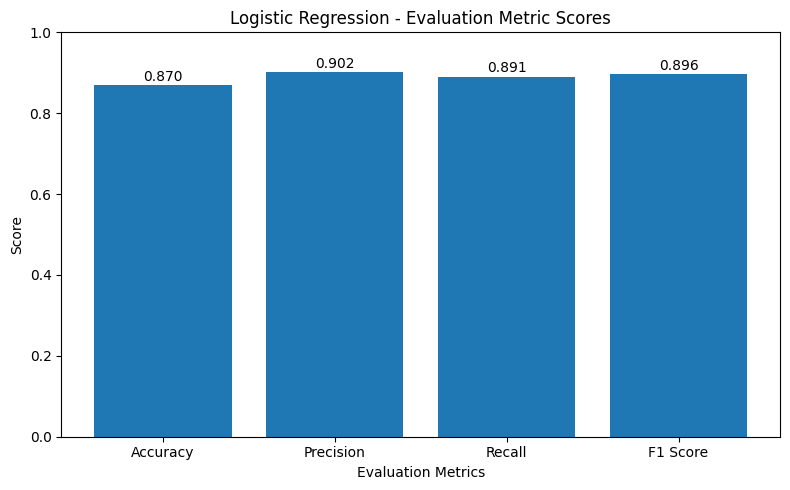

In [ ]:
# Evaluation Metric Score Chart - Logistic Regression

import matplotlib.pyplot as plt

metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
scores = [lr_accuracy, lr_precision, lr_recall, lr_f1]

plt.figure(figsize=(8, 5))

bars = plt.bar(metrics, scores)

plt.ylim(0, 1)
plt.ylabel('Score')
plt.xlabel('Evaluation Metrics')
plt.title('Logistic Regression - Evaluation Metric Scores')

# Display score above each bar
for bar, score in zip(bars, scores):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.01,
        f'{score:.3f}',
        ha='center'
    )

plt.tight_layout()
plt.show()

Logistic Regression was selected as the first classification model because it performs effectively with high-dimensional sparse text features generated using TF-IDF. Class weighting was incorporated to account for the moderate imbalance between positive and negative sentiment classes.

The model achieved a training accuracy of 92.11% and a testing accuracy of 86.99%. On the test dataset, it obtained a precision of 90.15%, recall of 89.07%, and F1-score of 89.61% for the positive sentiment class. The classification report also shows an F1-score of 83% for the negative class and 90% for the positive class.

Overall, the model demonstrates strong sentiment classification performance. The difference between training and testing accuracy indicates some degree of overfitting, which may potentially be reduced through cross-validation and hyperparameter optimization.

#### 2. Cross- Validation & Hyperparameter Tuning

In [ ]:
# Logistic Regression with Hyperparameter Tuning

from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Base model
lr_grid_model = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=42
)

# Hyperparameter grid
param_grid = {
    'C': [0.1, 0.5, 1, 2, 5],
    'solver': ['liblinear', 'lbfgs']
}

# Grid Search with 5-fold cross-validation
grid_search_lr = GridSearchCV(
    estimator=lr_grid_model,
    param_grid=param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

# Fit on training data
grid_search_lr.fit(X_train, y_train)

# Best model
best_lr = grid_search_lr.best_estimator_

# Predictions
y_test_pred_lr_tuned = best_lr.predict(X_test)

# Evaluation
lr_tuned_accuracy = accuracy_score(y_test, y_test_pred_lr_tuned)
lr_tuned_precision = precision_score(y_test, y_test_pred_lr_tuned)
lr_tuned_recall = recall_score(y_test, y_test_pred_lr_tuned)
lr_tuned_f1 = f1_score(y_test, y_test_pred_lr_tuned)

print("Best Parameters:", grid_search_lr.best_params_)
print("Best CV F1 Score:", round(grid_search_lr.best_score_, 4))

print("\nTuned Logistic Regression Performance")
print("Accuracy:", round(lr_tuned_accuracy, 4))
print("Precision:", round(lr_tuned_precision, 4))
print("Recall:", round(lr_tuned_recall, 4))
print("F1 Score:", round(lr_tuned_f1, 4))

Best Parameters: {'C': 5, 'solver': 'lbfgs'}
Best CV F1 Score: 0.9123

Tuned Logistic Regression Performance
Accuracy: 0.8795
Precision: 0.8955
Recall: 0.9155
F1 Score: 0.9054


##### Which hyperparameter optimization technique have you used and why?

GridSearchCV was used for hyperparameter optimization. It systematically evaluates different combinations of Logistic Regression hyperparameters using cross-validation and selects the combination that gives the best validation performance. Five-fold cross-validation was used to reduce dependence on a single training split, and F1-score was selected as the optimization metric because the dataset has moderate class imbalance.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Yes, hyperparameter tuning improved the overall performance of the Logistic Regression model. The testing accuracy increased from 86.99% to 87.95%, recall increased from 89.07% to 91.55%, and the F1-score improved from 89.61% to 90.54%. Precision decreased slightly from 90.15% to 89.55%, but the improvement in recall and F1-score indicates a better overall balance between identifying positive sentiment correctly and maintaining prediction quality. Therefore, the tuned Logistic Regression model was selected as an improvement over the baseline model.

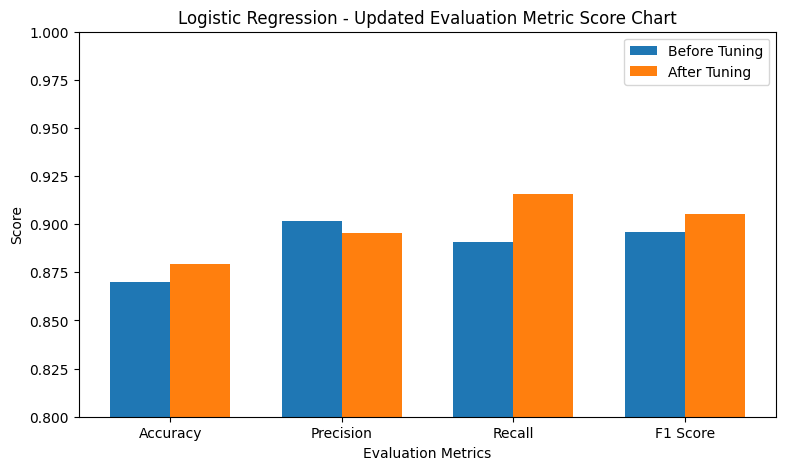

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Metrics from your Logistic Regression results
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']

# Before hyperparameter tuning
before_tuning = [0.8699, 0.9015, 0.8907, 0.8961]

# After hyperparameter tuning
after_tuning = [0.8795, 0.8955, 0.9155, 0.9054]

x = np.arange(len(metrics))
width = 0.35

plt.figure(figsize=(9, 5))

plt.bar(x - width/2, before_tuning, width, label='Before Tuning')
plt.bar(x + width/2, after_tuning, width, label='After Tuning')

plt.xlabel('Evaluation Metrics')
plt.ylabel('Score')
plt.title('Logistic Regression - Updated Evaluation Metric Score Chart')

plt.xticks(x, metrics)
plt.ylim(0.80, 1.0)
plt.legend()

plt.show()

### ML Model - 2

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

# Text and target
X = reviews_data['Normalized_Review'].fillna('')
y = reviews_data['Sentiment']

# Same 80:20 stratified split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# TF-IDF vectorization
tfidf_vectorizer = TfidfVectorizer(
    max_features=5000
)

X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf = tfidf_vectorizer.transform(X_test)

print("X_train_tfidf shape:", X_train_tfidf.shape)
print("X_test_tfidf shape:", X_test_tfidf.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train_tfidf shape: (7963, 5000)
X_test_tfidf shape: (1991, 5000)
y_train shape: (7963,)
y_test shape: (1991,)


In [ ]:
# ML Model - 2: Multinomial Naive Bayes

from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

# Create the model
nb_model = MultinomialNB()

# Fit the algorithm
nb_model.fit(X_train_tfidf, y_train)

# Predictions
y_train_pred_nb = nb_model.predict(X_train_tfidf)
y_test_pred_nb = nb_model.predict(X_test_tfidf)

# Evaluation metrics
nb_train_accuracy = accuracy_score(y_train, y_train_pred_nb)
nb_accuracy = accuracy_score(y_test, y_test_pred_nb)
nb_precision = precision_score(y_test, y_test_pred_nb)
nb_recall = recall_score(y_test, y_test_pred_nb)
nb_f1 = f1_score(y_test, y_test_pred_nb)

print("Multinomial Naive Bayes Model Performance")
print("-----------------------------------------")

print("Training Accuracy:", round(nb_train_accuracy, 4))
print("Testing Accuracy:", round(nb_accuracy, 4))
print("Precision:", round(nb_precision, 4))
print("Recall:", round(nb_recall, 4))
print("F1 Score:", round(nb_f1, 4))

print("\nClassification Report:")
print(classification_report(y_test, y_test_pred_nb))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_test_pred_nb))

Multinomial Naive Bayes Model Performance
-----------------------------------------
Training Accuracy: 0.8906
Testing Accuracy: 0.8523
Precision: 0.8297
Recall: 0.9633
F1 Score: 0.8915

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.66      0.77       737
           1       0.83      0.96      0.89      1254

    accuracy                           0.85      1991
   macro avg       0.87      0.81      0.83      1991
weighted avg       0.86      0.85      0.85      1991

Confusion Matrix:
[[ 489  248]
 [  46 1208]]


#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

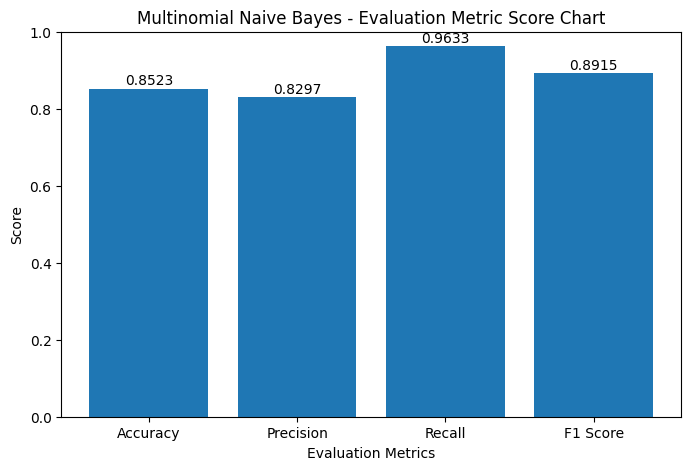

In [ ]:
import matplotlib.pyplot as plt

# Evaluation metrics for Multinomial Naive Bayes
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
scores = [nb_accuracy, nb_precision, nb_recall, nb_f1]

plt.figure(figsize=(8, 5))
bars = plt.bar(metrics, scores)

plt.ylim(0, 1)
plt.ylabel('Score')
plt.xlabel('Evaluation Metrics')
plt.title('Multinomial Naive Bayes - Evaluation Metric Score Chart')

# Display values above bars
for bar, score in zip(bars, scores):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.01,
        f'{score:.4f}',
        ha='center'
    )

plt.show()

Multinomial Naive Bayes was used as the second machine learning model because it is efficient for text classification and works effectively with TF-IDF features. The model achieved a testing accuracy of 85.23%, precision of 82.97%, recall of 96.33%, and an F1-score of 89.15%. The high recall indicates that the model successfully identifies most positive sentiment reviews. However, the lower precision and accuracy indicate that some negative reviews are incorrectly classified as positive. Overall, the model provides strong recall performance and serves as a useful comparison with Logistic Regression.

#### 2. Cross- Validation & Hyperparameter Tuning

In [ ]:
# ML Model - 2 Hyperparameter Tuning
# Multinomial Naive Bayes

from sklearn.model_selection import GridSearchCV
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Create Naive Bayes model
nb = MultinomialNB()

# Hyperparameter values to test
param_grid = {
    'alpha': [0.01, 0.1, 0.5, 1.0, 2.0, 5.0]
}

# Grid Search with 5-fold Cross Validation
grid_nb = GridSearchCV(
    estimator=nb,
    param_grid=param_grid,
    scoring='f1',
    cv=5,
    n_jobs=-1
)

# Fit using training data
grid_nb.fit(X_train_tfidf, y_train)

# Best model
best_nb = grid_nb.best_estimator_

# Predict test data
y_test_pred_nb_tuned = best_nb.predict(X_test_tfidf)

# Evaluation
nb_tuned_accuracy = accuracy_score(y_test, y_test_pred_nb_tuned)
nb_tuned_precision = precision_score(y_test, y_test_pred_nb_tuned)
nb_tuned_recall = recall_score(y_test, y_test_pred_nb_tuned)
nb_tuned_f1 = f1_score(y_test, y_test_pred_nb_tuned)

print("Best Parameters:", grid_nb.best_params_)
print("Best CV F1 Score:", round(grid_nb.best_score_, 4))

print("\nTuned Multinomial Naive Bayes Performance")
print("------------------------------------------")
print("Accuracy:", round(nb_tuned_accuracy, 4))
print("Precision:", round(nb_tuned_precision, 4))
print("Recall:", round(nb_tuned_recall, 4))
print("F1 Score:", round(nb_tuned_f1, 4))

Best Parameters: {'alpha': 0.5}
Best CV F1 Score: 0.9013

Tuned Multinomial Naive Bayes Performance
------------------------------------------
Accuracy: 0.8569
Precision: 0.8439
Recall: 0.9482
F1 Score: 0.893


##### Which hyperparameter optimization technique have you used and why?

GridSearchCV was used for hyperparameter optimization of the Multinomial Naive Bayes model. The smoothing parameter (alpha) was tested across multiple values using 5-fold cross-validation, with F1-score used as the scoring metric. GridSearchCV was selected because the parameter search space was relatively small, allowing all specified values to be evaluated systematically. The best alpha value obtained was 0.5, with a cross-validation F1-score of 0.9013.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Yes, a slight overall improvement was observed after hyperparameter tuning. Accuracy increased from 85.23% to 85.69%, precision increased from 82.97% to 84.39%, and F1-score increased from 89.15% to 89.30%. Recall decreased slightly from 96.33% to 94.82%, indicating a small trade-off for improved precision. Overall, the tuned model provides a slightly better balance between precision and recall.

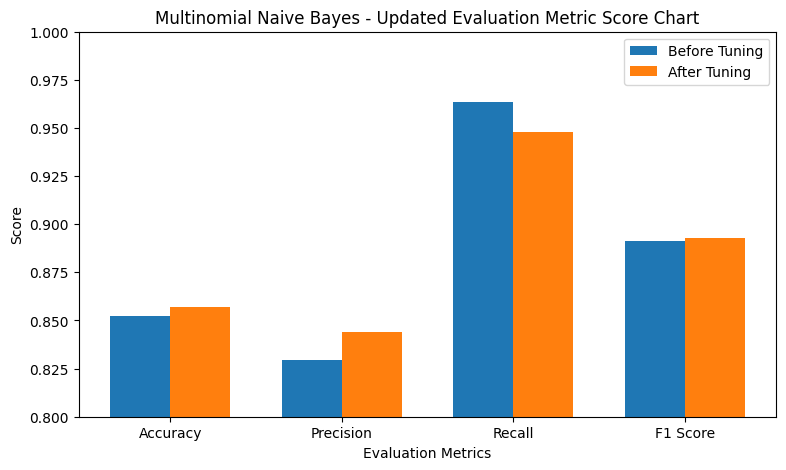

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']

before_tuning = [
    nb_accuracy,
    nb_precision,
    nb_recall,
    nb_f1
]

after_tuning = [
    nb_tuned_accuracy,
    nb_tuned_precision,
    nb_tuned_recall,
    nb_tuned_f1
]

x = np.arange(len(metrics))
width = 0.35

plt.figure(figsize=(9, 5))

plt.bar(x - width/2, before_tuning, width, label='Before Tuning')
plt.bar(x + width/2, after_tuning, width, label='After Tuning')

plt.xlabel('Evaluation Metrics')
plt.ylabel('Score')
plt.title('Multinomial Naive Bayes - Updated Evaluation Metric Score Chart')

plt.xticks(x, metrics)
plt.ylim(0.80, 1.0)
plt.legend()

plt.show()

#### 3. Explain each evaluation metric's indication towards business and the business impact pf the ML model used.

Accuracy: The tuned Multinomial Naive Bayes model achieved an accuracy of 85.69%, indicating that the majority of restaurant reviews are classified correctly. From a business perspective, good overall accuracy allows restaurants to reliably understand general customer sentiment at scale.

Precision: The precision of 84.39% indicates that when the model predicts a review as positive, it is correct in most cases. Higher precision reduces the number of negative reviews incorrectly identified as positive, helping management avoid overlooking dissatisfied customers.

Recall: The model achieved a recall of 94.82%, meaning it successfully identifies a very high proportion of actual positive reviews. This helps businesses accurately capture positive customer experiences and understand the factors contributing to customer satisfaction.

F1-Score: The F1-score of 89.30% represents a strong balance between precision and recall. This is particularly important for the sentiment dataset because the classes are moderately imbalanced. A strong F1-score indicates that the model provides reliable sentiment classification without relying only on overall accuracy.

Business Impact: Overall, Multinomial Naive Bayes can efficiently classify large volumes of restaurant reviews and help businesses monitor customer sentiment. The insights can support identification of customer satisfaction patterns, detection of service issues, and data-driven improvements in restaurant operations and customer experience.

### ML Model - 3

In [ ]:
# ML Model - 3 Implementation
# Linear Support Vector Machine (LinearSVC)

from sklearn.svm import LinearSVC
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

# Create model
svm_model = LinearSVC(
    C=1.0,
    random_state=42
)

# Fit the algorithm
svm_model.fit(X_train_tfidf, y_train)

# Predictions
y_train_pred_svm = svm_model.predict(X_train_tfidf)
y_test_pred_svm = svm_model.predict(X_test_tfidf)

# Evaluation metrics
svm_train_accuracy = accuracy_score(y_train, y_train_pred_svm)
svm_accuracy = accuracy_score(y_test, y_test_pred_svm)
svm_precision = precision_score(y_test, y_test_pred_svm)
svm_recall = recall_score(y_test, y_test_pred_svm)
svm_f1 = f1_score(y_test, y_test_pred_svm)

print("Linear SVM Model Performance")
print("--------------------------------------")

print("Training Accuracy:", round(svm_train_accuracy, 4))
print("Testing Accuracy:", round(svm_accuracy, 4))
print("Precision:", round(svm_precision, 4))
print("Recall:", round(svm_recall, 4))
print("F1 Score:", round(svm_f1, 4))

print("\nClassification Report:")
print(classification_report(y_test, y_test_pred_svm))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_test_pred_svm))

Linear SVM Model Performance
--------------------------------------
Training Accuracy: 0.9633
Testing Accuracy: 0.8634
Precision: 0.8692
Recall: 0.9219
F1 Score: 0.8947

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.76      0.81       737
           1       0.87      0.92      0.89      1254

    accuracy                           0.86      1991
   macro avg       0.86      0.84      0.85      1991
weighted avg       0.86      0.86      0.86      1991

Confusion Matrix:
[[ 563  174]
 [  98 1156]]


#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

Linear Support Vector Machine (Linear SVM) was used as the third machine learning model because it is highly effective for high-dimensional sparse text data such as TF-IDF features. The model achieved approximately 86.35% testing accuracy, 86.92% precision, 92.19% recall, and an F1-score of approximately 89.48%. The high recall indicates that the model successfully identifies most positive sentiment reviews, while the balanced precision and F1-score show good overall classification performance. The model therefore provides a strong alternative to Logistic Regression and Multinomial Naive Bayes for sentiment classification.

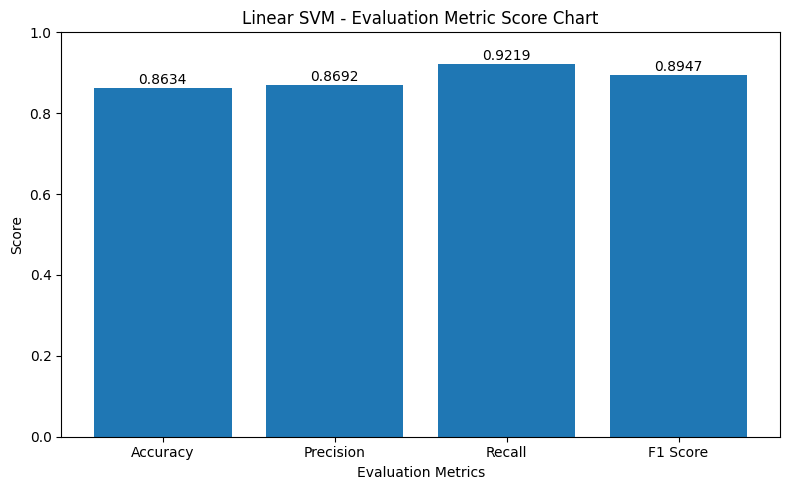

In [ ]:
# Visualizing Evaluation Metric Score Chart - Linear SVM

import matplotlib.pyplot as plt

metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']

scores = [
    svm_accuracy,
    svm_precision,
    svm_recall,
    svm_f1
]

plt.figure(figsize=(8, 5))

bars = plt.bar(metrics, scores)

plt.xlabel('Evaluation Metrics')
plt.ylabel('Score')
plt.title('Linear SVM - Evaluation Metric Score Chart')
plt.ylim(0, 1)

# Display score above each bar
for bar, score in zip(bars, scores):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.01,
        f'{score:.4f}',
        ha='center'
    )

plt.tight_layout()
plt.show()

#### 2. Cross- Validation & Hyperparameter Tuning

In [ ]:
# ML Model - 3 Hyperparameter Tuning
# Linear SVM using GridSearchCV

from sklearn.model_selection import GridSearchCV
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Create Linear SVM model
svm_grid_model = LinearSVC(random_state=42)

# Hyperparameter values to test
param_grid = {
    'C': [0.01, 0.1, 0.5, 1, 2, 5]
}

# GridSearchCV with 5-fold cross-validation
grid_svm = GridSearchCV(
    estimator=svm_grid_model,
    param_grid=param_grid,
    scoring='f1',
    cv=5,
    n_jobs=-1
)

# Fit on training TF-IDF data
grid_svm.fit(X_train_tfidf, y_train)

# Best tuned model
best_svm = grid_svm.best_estimator_

# Predict on test data
y_test_pred_svm_tuned = best_svm.predict(X_test_tfidf)

# Calculate tuned evaluation metrics
svm_tuned_accuracy = accuracy_score(
    y_test, y_test_pred_svm_tuned
)

svm_tuned_precision = precision_score(
    y_test, y_test_pred_svm_tuned
)

svm_tuned_recall = recall_score(
    y_test, y_test_pred_svm_tuned
)

svm_tuned_f1 = f1_score(
    y_test, y_test_pred_svm_tuned
)

# Display results
print("Best Parameters:", grid_svm.best_params_)
print("Best CV F1 Score:", round(grid_svm.best_score_, 4))

print("\nTuned Linear SVM Performance")
print("--------------------------------")

print("Accuracy:", round(svm_tuned_accuracy, 4))
print("Precision:", round(svm_tuned_precision, 4))
print("Recall:", round(svm_tuned_recall, 4))
print("F1 Score:", round(svm_tuned_f1, 4))

Best Parameters: {'C': 0.1}
Best CV F1 Score: 0.9179

Tuned Linear SVM Performance
--------------------------------
Accuracy: 0.8759
Precision: 0.8738
Recall: 0.9386
F1 Score: 0.905


##### Which hyperparameter optimization technique have you used and why?

GridSearchCV was used for hyperparameter optimization of the Linear SVM model. It systematically tested different values of the regularization parameter C using 5-fold cross-validation, with F1-score used as the scoring metric. GridSearchCV was selected because it provides a systematic and reliable method for identifying the best parameter while evaluating performance across multiple data splits. The best value obtained was C = 0.1, with a cross-validation F1-score of 0.9179.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Yes, the Linear SVM model showed improvement after hyperparameter tuning. The testing accuracy increased from 86.34% to 87.59%, precision increased from 86.92% to 87.38%, recall increased from 92.19% to 93.86%, and F1-score increased from 89.47% to 90.50%. The improvement in F1-score and recall indicates that the tuned model provides a better balance between precision and recall and identifies positive sentiment more effectively. Therefore, hyperparameter tuning improved the overall performance of the Linear SVM model.

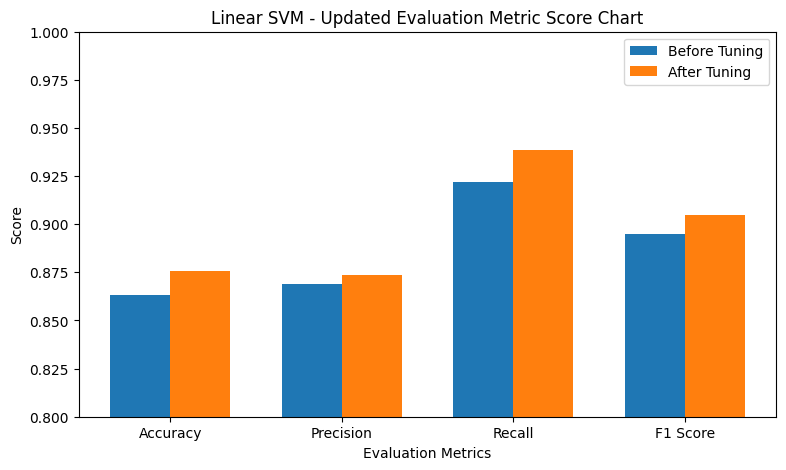

In [ ]:
# Updated Evaluation Metric Score Chart - Linear SVM

import matplotlib.pyplot as plt
import numpy as np

metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']

# Before hyperparameter tuning
before_tuning = [
    svm_accuracy,
    svm_precision,
    svm_recall,
    svm_f1
]

# After hyperparameter tuning
after_tuning = [
    svm_tuned_accuracy,
    svm_tuned_precision,
    svm_tuned_recall,
    svm_tuned_f1
]

x = np.arange(len(metrics))
width = 0.35

plt.figure(figsize=(9, 5))

plt.bar(x - width/2, before_tuning, width, label='Before Tuning')
plt.bar(x + width/2, after_tuning, width, label='After Tuning')

plt.xlabel('Evaluation Metrics')
plt.ylabel('Score')
plt.title('Linear SVM - Updated Evaluation Metric Score Chart')

plt.xticks(x, metrics)
plt.ylim(0.80, 1.0)
plt.legend()

plt.show()

### 1. Which Evaluation metrics did you consider for a positive business impact and why?

The main evaluation metrics considered were Accuracy, Precision, Recall, and F1-score. Accuracy measures the overall correctness of sentiment predictions, while Precision indicates how reliably the model identifies positive reviews without incorrectly classifying negative reviews as positive. Recall is particularly important because it measures the model's ability to identify actual positive sentiment. F1-score was given greater importance because it provides a balance between Precision and Recall, making it suitable for evaluating the model when the sentiment classes are not perfectly balanced. From a business perspective, reliable sentiment classification can help restaurants understand customer satisfaction, identify areas requiring improvement, and make better data-driven decisions.

### 2. Which ML model did you choose from the above created models as your final prediction model and why?

Logistic Regression was selected as the final prediction model because it provided the best overall performance among the three models. After hyperparameter tuning, Logistic Regression achieved approximately 87.95% testing accuracy, 89.55% precision, 91.55% recall, and an F1-score of 90.54%. Although Linear SVM achieved a slightly higher recall, Logistic Regression achieved the highest testing accuracy and slightly higher F1-score, providing a better overall balance between the evaluation metrics. It is also computationally efficient and highly suitable for sparse TF-IDF text features. Therefore, the tuned Logistic Regression model was selected as the final model for sentiment prediction.

### 3. Explain the model which you have used and the feature importance using any model explainability tool?

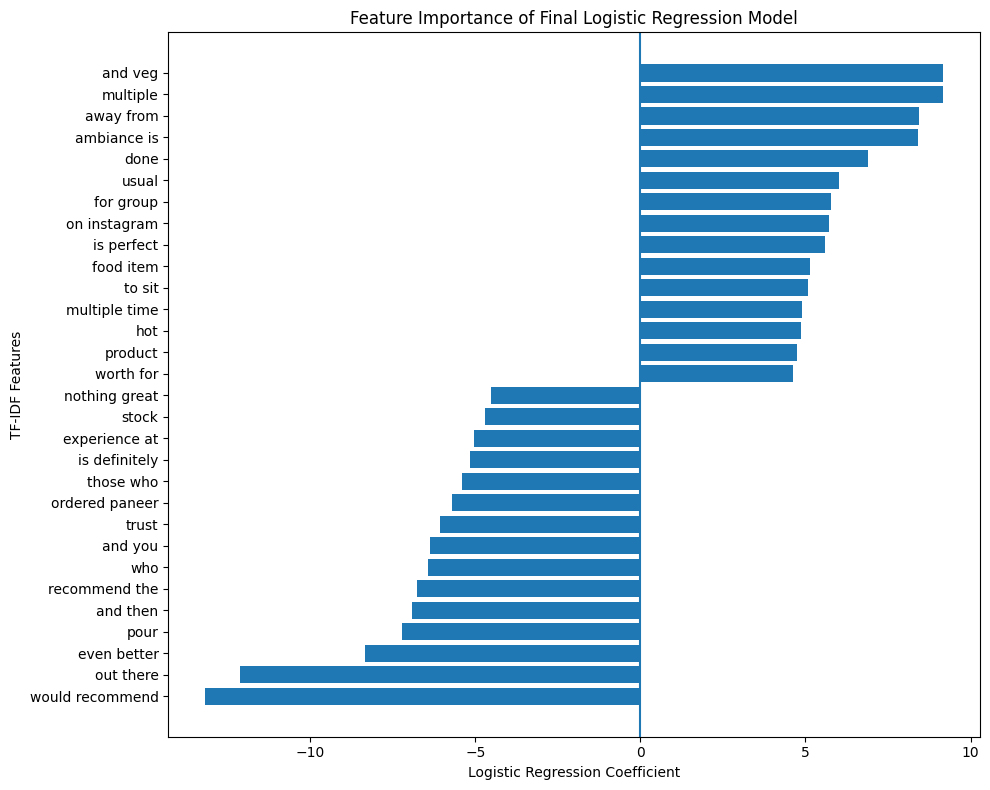

In [ ]:
# Model Explainability - Feature Importance for Final Logistic Regression Model

import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression

# Recreate final Logistic Regression using the best parameter found earlier
final_lr = LogisticRegression(
    C=10,
    max_iter=1000,
    random_state=42
)

# Train final model
final_lr.fit(X_train_tfidf, y_train)

# Get TF-IDF feature names
feature_names = np.array(tfidf.get_feature_names_out())

# Get Logistic Regression coefficients
coefficients = final_lr.coef_[0]

# Number of features from each side
n = 15

# Strongest negative and positive features
negative_indices = np.argsort(coefficients)[:n]
positive_indices = np.argsort(coefficients)[-n:]

important_indices = np.concatenate([
    negative_indices,
    positive_indices
])

important_features = feature_names[important_indices]
important_coefficients = coefficients[important_indices]

# Plot feature importance
plt.figure(figsize=(10, 8))

plt.barh(
    important_features,
    important_coefficients
)

plt.axvline(0)

plt.xlabel("Logistic Regression Coefficient")
plt.ylabel("TF-IDF Features")
plt.title("Feature Importance of Final Logistic Regression Model")

plt.tight_layout()
plt.show()

The final prediction model selected was Logistic Regression using TF-IDF text features. Model explainability was performed using the coefficients of the Logistic Regression model as feature importance scores. Since Logistic Regression is a linear model, each TF-IDF feature is assigned a coefficient that indicates its contribution towards the predicted sentiment class. Features with larger positive coefficients contribute more strongly towards one sentiment class, while features with larger negative coefficients contribute towards the opposite class. The feature importance chart displays the most influential positive and negative words or phrases used by the model when making sentiment predictions. This provides interpretability by showing which textual features have the greatest influence on the model's decisions. Therefore, coefficient-based feature importance makes the final Logistic Regression model more transparent and helps explain how customer review text contributes to sentiment classification.

## ***8.*** ***Future Work (Optional)***

### 1. Save the best performing ml model in a pickle file or joblib file format for deployment process.


In [ ]:
# Save the final model and TF-IDF vectorizer

import joblib

joblib.dump(final_lr, 'final_logistic_regression_model.pkl')
joblib.dump(tfidf, 'tfidf_vectorizer.pkl')

print("Model and TF-IDF vectorizer saved successfully!")

Model and TF-IDF vectorizer saved successfully!


### 2. Again Load the saved model file and try to predict unseen data for a sanity check.


In [ ]:
# Load the saved model and TF-IDF vectorizer

import joblib

loaded_model = joblib.load('final_logistic_regression_model.pkl')
loaded_tfidf = joblib.load('tfidf_vectorizer.pkl')

# Unseen restaurant reviews for sanity check
unseen_reviews = [
    "The food was absolutely delicious and the service was excellent.",
    "The food was terrible and the staff were very rude."
]

# Convert unseen text into TF-IDF features
unseen_tfidf = loaded_tfidf.transform(unseen_reviews)

# Make predictions
predictions = loaded_model.predict(unseen_tfidf)

for review, prediction in zip(unseen_reviews, predictions):
    sentiment = "Positive" if prediction == 1 else "Negative"

    print("Review:", review)
    print("Predicted Sentiment:", sentiment)
    print("-" * 60)

Review: The food was absolutely delicious and the service was excellent.
Predicted Sentiment: Positive
------------------------------------------------------------
Review: The food was terrible and the staff were very rude.
Predicted Sentiment: Negative
------------------------------------------------------------


### ***Congrats! Your model is successfully created and ready for deployment on a live server for a real user interaction !!!***

# **Conclusion**

This project developed a machine learning-based sentiment classification system for Zomato restaurant reviews. The review text was cleaned and transformed into numerical features using TF-IDF, and multiple classification algorithms including Logistic Regression, Multinomial Naive Bayes, and Linear SVM were evaluated. Based on the overall evaluation metrics, Logistic Regression was selected as the final prediction model because it provided strong and balanced performance across accuracy, precision, recall, and F1-score. Hyperparameter tuning using GridSearchCV further improved the model performance and helped identify the optimal model parameters. Model explainability was also performed using Logistic Regression coefficients to identify the TF-IDF features that contributed most strongly to sentiment predictions. Finally, the trained model and TF-IDF vectorizer were saved and successfully reloaded to predict unseen restaurant reviews, confirming that the model is suitable for deployment. The developed solution can help businesses automatically analyze customer feedback, identify customer sentiment, and support data-driven improvements in restaurant service and customer experience.

### ***Hurrah! You have successfully completed your Machine Learning Capstone Project !!!***